## Cell 1 - Imports & Device (v6.5 Multi-Seed Ablation Fed-DDQN)

In [1]:
import os, time, random, warnings, json, hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve,
    classification_report, accuracy_score, f1_score
)
from torch.utils.data import TensorDataset, DataLoader
from collections import deque
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42); random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"
print("PyTorch:", torch.__version__, "| Device:", device, "| pin_memory:", PIN_MEMORY)

PyTorch: 2.2.2+cu121 | Device: cuda | pin_memory: True


## Cell 2 – Load Datasets

Update `base_path` to wherever your CSVs live.

In [2]:
# Change this path to where your CSVs are saved.
base_path = r"C:\Users\mayan\Desktop\3STSEM\ai\model\dataset3"

# Runtime controls. Keep MAX_STEPS unchanged later; use caches/validation to reduce runtime.
FORCE_REBUILD_FEATURES = False
FORCE_RETRAIN_FED_DDQN = False
FORCE_RETRAIN_BASELINES = False
FORCE_RETRAIN_ALLOCATOR = False
RUN_FULL_ANALYTICS = True
RUN_PLOTS = True
LOAD_EXPERIMENT_RESULTS_ONLY = False

# v6.5 experiment-suite controls.
# Efficient default uses three seeds. For final paper, set MULTI_SEED_QUICK_MODE=False.
RUN_MULTI_SEED_ABLATION = True
FORCE_RETRAIN_MULTI_SEED_ABLATION = False
MULTI_SEED_QUICK_MODE = True
FINAL_PAPER_SEEDS = [42, 77, 123, 2025, 999]
QUICK_EXPERIMENT_SEEDS = [42, 77, 123]
EXPERIMENT_SEEDS = QUICK_EXPERIMENT_SEEDS if MULTI_SEED_QUICK_MODE else FINAL_PAPER_SEEDS
CACHE_VERSION = "v65_multiseed_ablation_2026_05_21"

cache_dir = os.path.join(base_path, "_v64_cache")
os.makedirs(cache_dir, exist_ok=True)

tasks         = pd.read_csv(os.path.join(base_path, "dataset_A.csv"))
edge_nodes    = pd.read_csv(os.path.join(base_path, "edge_nodes.csv"))
edge_state    = pd.read_csv(os.path.join(base_path, "edge_state.csv"))
cloud_nodes   = pd.read_csv(os.path.join(base_path, "cloud_nodes.csv"))
cloud_state   = pd.read_csv(os.path.join(base_path, "cloud_state.csv"))
network_state = pd.read_csv(os.path.join(base_path, "network_state.csv"))

_DATASET_FILES = [
    ("tasks", "dataset_A.csv", tasks),
    ("edge_nodes", "edge_nodes.csv", edge_nodes),
    ("edge_state", "edge_state.csv", edge_state),
    ("cloud_nodes", "cloud_nodes.csv", cloud_nodes),
    ("cloud_state", "cloud_state.csv", cloud_state),
    ("network_state", "network_state.csv", network_state),
]

def _build_cache_signature():
    payload = {"cache_version": CACHE_VERSION, "files": {}, "schemas": {}, "rows": {}}
    for name, filename, df in _DATASET_FILES:
        path = os.path.join(base_path, filename)
        stat = os.stat(path)
        payload["files"][filename] = {"size": stat.st_size, "mtime_ns": stat.st_mtime_ns}
        payload["schemas"][name] = list(df.columns)
        payload["rows"][name] = int(len(df))
    raw = json.dumps(payload, sort_keys=True).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()

cache_signature = _build_cache_signature()
cache_prefix = f"v64_{cache_signature[:16]}"
labels_cache_path = os.path.join(cache_dir, f"{cache_prefix}_labels.npz")
features_cache_path = os.path.join(cache_dir, f"{cache_prefix}_features.npz")
alloc_targets_cache_path = os.path.join(cache_dir, f"{cache_prefix}_alloc_targets.npz")
fed_model_path = os.path.join(cache_dir, f"{cache_prefix}_fed_ddqn_best.pt")
cent_model_path = os.path.join(cache_dir, f"{cache_prefix}_cent_ddqn.pt")
feddpg_model_path = os.path.join(cache_dir, f"{cache_prefix}_flddpg.pt")
baseline_meta_path = os.path.join(cache_dir, f"{cache_prefix}_baselines_meta.pt")
allocator_model_path = os.path.join(cache_dir, f"{cache_prefix}_allocator.pt")
multiseed_cache_dir = os.path.join(cache_dir, "multiseed_ablation")
os.makedirs(multiseed_cache_dir, exist_ok=True)
results_cache_path = os.path.join(multiseed_cache_dir, f"{cache_prefix}_multiseed_ablation_results.pkl")
actions_cache_path = os.path.join(multiseed_cache_dir, f"{cache_prefix}_test_actions.pkl")
scenario_mask_cache_path = os.path.join(multiseed_cache_dir, f"{cache_prefix}_scenario_masks.npz")

for name, df in [("tasks",tasks),("edge_nodes",edge_nodes),("edge_state",edge_state),
                 ("cloud_nodes",cloud_nodes),("cloud_state",cloud_state),("network_state",network_state)]:
    print(f"{name:<15}: {df.shape}")
print("\nTask type distribution:\n", tasks["task_type"].value_counts())
print(f"\nCache directory: {cache_dir}")
print(f"Cache signature: {cache_signature[:16]}")
print("Runtime flags:")
print(f"  FORCE_REBUILD_FEATURES={FORCE_REBUILD_FEATURES}")
print(f"  FORCE_RETRAIN_FED_DDQN={FORCE_RETRAIN_FED_DDQN}")
print(f"  FORCE_RETRAIN_BASELINES={FORCE_RETRAIN_BASELINES}")
print(f"  FORCE_RETRAIN_ALLOCATOR={FORCE_RETRAIN_ALLOCATOR}")
print(f"  RUN_FULL_ANALYTICS={RUN_FULL_ANALYTICS}")
print(f"  RUN_PLOTS={RUN_PLOTS}")
print(f"  LOAD_EXPERIMENT_RESULTS_ONLY={LOAD_EXPERIMENT_RESULTS_ONLY}")
print(f"  RUN_MULTI_SEED_ABLATION={RUN_MULTI_SEED_ABLATION}")
print(f"  FORCE_RETRAIN_MULTI_SEED_ABLATION={FORCE_RETRAIN_MULTI_SEED_ABLATION}")
print(f"  MULTI_SEED_QUICK_MODE={MULTI_SEED_QUICK_MODE}")
print(f"  EXPERIMENT_SEEDS={EXPERIMENT_SEEDS}")

tasks          : (100000, 23)
edge_nodes     : (50, 8)
edge_state     : (50000, 10)
cloud_nodes    : (10, 6)
cloud_state    : (10000, 9)
network_state  : (1000, 11)

Task type distribution:
 task_type
sensor             27673
image              18308
ai                 10622
telemetry          10560
video               9710
voice               9088
firmware_update     7546
emergency           6493
Name: count, dtype: int64

Cache directory: C:\Users\mayan\Desktop\3STSEM\ai\model\dataset3\_v64_cache
Cache signature: 9b3994af16ecb471
Runtime flags:
  FORCE_REBUILD_FEATURES=False
  FORCE_RETRAIN_FED_DDQN=False
  FORCE_RETRAIN_BASELINES=False
  FORCE_RETRAIN_ALLOCATOR=False
  RUN_FULL_ANALYTICS=True
  RUN_PLOTS=True
  LOAD_EXPERIMENT_RESULTS_ONLY=False
  RUN_MULTI_SEED_ABLATION=True
  FORCE_RETRAIN_MULTI_SEED_ABLATION=False
  MULTI_SEED_QUICK_MODE=True
  EXPERIMENT_SEEDS=[42, 77, 123]


## Cell 3 – QoS Parameters + Zone Mapping

[FIX 3] Build a `zone` column on `tasks` from `edge_nodes.location_zone`, used later for non-IID federated client splits.

In [3]:
QUEUE_THRESHOLD        = 30
PACKET_LOSS_THRESHOLD  = 0.15
BANDWIDTH_THRESHOLD    = 80
SNR_THRESHOLD          = 5.0
ENERGY_FLOOR           = 50.0

# SLA targets per task type (ms)
SLA_MS = {
    "emergency": 50, "voice": 150, "sensor": 500, "telemetry": 800,
    "image": 1500, "video": 3000, "ai": 5000, "firmware_update": 60000,
}

EDGE_LAT_CAP  = 500.0
CLOUD_LAT_CAP = 800.0

# ── Zone mapping: edge_id -> location_zone ──────────────────────────────────
# [FIX 3] This drives the non-IID federated split later.
edge_zone_map  = dict(zip(edge_nodes["edge_id"], edge_nodes["location_zone"]))
zone_edge_ids  = {}
for eid, zone in edge_zone_map.items():
    zone_edge_ids.setdefault(zone, []).append(eid)

# Attach zone to every task row
tasks["zone"] = tasks["assigned_edge_id"].map(edge_zone_map).fillna("urban")

print("Parameters loaded.")
print(f"Edge cap={EDGE_LAT_CAP} ms  |  Cloud cap={CLOUD_LAT_CAP} ms")
print("\nZone distribution:")
print(tasks["zone"].value_counts())
print("\nAvailable zones (client names):", sorted(zone_edge_ids.keys()))


Parameters loaded.
Edge cap=500.0 ms  |  Cloud cap=800.0 ms

Zone distribution:
zone
urban         43928
suburban      42043
rural         10048
industrial     3981
Name: count, dtype: int64

Available zones (client names): ['industrial', 'rural', 'suburban', 'urban']


## Cell 4 – Build Fast Lookup Indexes

In [4]:
print("Building lookup indexes ...")
edge_idx = {}
for row in edge_state.itertuples(index=False):
    edge_idx[(int(row.timestep), int(row.edge_id))] = row

net_idx = {}
for row in network_state.itertuples(index=False):
    net_idx[int(row.timestep)] = row

cloud_idx = {}
for row in cloud_state.itertuples(index=False):
    cloud_idx.setdefault(int(row.timestep), []).append(row)

print(f"edge_idx: {len(edge_idx):,} | net_idx: {len(net_idx):,} | cloud_idx: {len(cloud_idx):,}")


Building lookup indexes ...
edge_idx: 50,000 | net_idx: 1,000 | cloud_idx: 1,000


## Cell 5 – compute_latency() — No Sentinel Pollution

In [5]:
def compute_latency(task_row):
    t       = int(task_row["arrival_time"])
    edge_id = int(task_row["assigned_edge_id"])

    edge   = edge_idx.get((t, edge_id))
    net    = net_idx.get(t)
    c_rows = cloud_idx.get(t, [])

    if edge is None or net is None or not c_rows:
        return 1, 1, EDGE_LAT_CAP, CLOUD_LAT_CAP
    if getattr(edge, "is_failed", 0) == 1:
        return 1, 1, EDGE_LAT_CAP, CLOUD_LAT_CAP
    if getattr(net, "is_outage", 0) == 1:
        return 1, 1, EDGE_LAT_CAP, CLOUD_LAT_CAP
    if task_row.get("is_corrupt", 0) == 1:
        return int(np.random.rand() > 0.5), 1, EDGE_LAT_CAP, CLOUD_LAT_CAP

    avail_c        = [r for r in c_rows if getattr(r, "is_in_maintenance", 0) == 0] or c_rows
    cloud_cpu      = float(np.mean([r.cloud_cpu_available   for r in avail_c]))
    cloud_lat_base = float(np.mean([r.cloud_latency_current for r in avail_c]))

    snr_factor   = float(np.clip(getattr(net, "snr_db", 25) / 25.0, 0.1, 1.5))
    effective_bw = max(float(net.uplink_bandwidth) * (1.0 - float(net.packet_loss_rate)) * snr_factor, 1.0)

    cpu_c  = float(task_row["cpu_cycles"])
    size_c = float(task_row["task_size_mb"])

    edge_latency = cpu_c / max(float(edge.edge_cpu_available), 1e-3) + float(edge.edge_queue_length) * 0.5
    if getattr(edge, "is_degrading", 0) == 1: edge_latency *= 1.35
    if task_row.get("is_low_battery", 0) == 1: edge_latency *= 1.20
    edge_latency = min(edge_latency, EDGE_LAT_CAP)

    cold_penalty  = 200.0 if (avail_c and getattr(avail_c[0], "had_cold_start", 0) == 1) else 0.0
    cloud_latency = min(
        size_c / effective_bw + cpu_c / max(cloud_cpu, 1e-3)
        + float(net.network_delay_ms) + cloud_lat_base + cold_penalty,
        CLOUD_LAT_CAP
    )
    if getattr(net, "is_jitter_storm", 0) == 1:
        cloud_latency = min(cloud_latency + float(np.random.exponential(30)), CLOUD_LAT_CAP)

    if task_row.get("impossible_deadline", 0) == 1:
        return 1, 1, edge_latency, cloud_latency

    rejected = int(
        float(edge.edge_queue_length)        > QUEUE_THRESHOLD        or
        float(net.packet_loss_rate)          > PACKET_LOSS_THRESHOLD  or
        effective_bw                         < BANDWIDTH_THRESHOLD    or
        float(edge.edge_energy_level)        < ENERGY_FLOOR           or
        float(getattr(net, "snr_db", 99.0)) < SNR_THRESHOLD
    )
    if task_row.get("task_type", "") == "emergency":
        rejected = 0   # emergency tasks are never QoS-rejected

    decision = 1 if rejected else (0 if edge_latency < cloud_latency else 1)
    return decision, rejected, edge_latency, cloud_latency

print("compute_latency() ready.")


compute_latency() ready.


## Cell 6 – Generate Labels + Fixed rejection_flag

[FIX 1] `rejection_flag` is recomputed as a proper binary target:
- `impossible_deadline == 1`, **OR**
- both `edge_latency > SLA` and `cloud_latency > SLA`

This is separate from `rejected` (QoS-threshold flag used in reward).

In [6]:
labels_cache_loaded = False

if (not FORCE_REBUILD_FEATURES) and os.path.exists(labels_cache_path):
    try:
        cache = np.load(labels_cache_path)
        if int(cache["n_tasks"][0]) != len(tasks):
            raise ValueError("cached label row count does not match current tasks")
        tasks["offload_label"] = cache["offload_label"].astype(int)
        tasks["rejected"] = cache["rejected"].astype(int)
        tasks["edge_latency"] = cache["edge_latency"].astype(float)
        tasks["cloud_latency"] = cache["cloud_latency"].astype(float)
        tasks["rejection_flag"] = cache["rejection_flag"].astype(int)
        tasks["sla_violated"] = cache["sla_violated"].astype(int)
        labels_cache_loaded = True
        print(f"Loaded cached labels/latencies: {labels_cache_path}")
    except Exception as exc:
        print(f"Label cache ignored and rebuilt: {exc}")

if not labels_cache_loaded:
    print(f"Generating labels for {len(tasks):,} tasks ...")
    t0 = time.time()
    decisions, rejections, edge_lats, cloud_lats = [], [], [], []
    for _, row in tasks.iterrows():
        d, r, el, cl = compute_latency(row)
        decisions.append(d); rejections.append(r)
        edge_lats.append(el); cloud_lats.append(cl)

    tasks["offload_label"] = decisions
    tasks["rejected"] = rejections
    tasks["edge_latency"] = edge_lats
    tasks["cloud_latency"] = cloud_lats

    sla_arr = tasks["task_type"].map(SLA_MS).fillna(9999).values.astype(float)
    tasks["rejection_flag"] = (
        (tasks["impossible_deadline"] == 1) |
        ((tasks["edge_latency"] > sla_arr) & (tasks["cloud_latency"] > sla_arr))
    ).astype(int)
    chosen_latency = np.where(tasks["offload_label"].values == 0, tasks["edge_latency"].values, tasks["cloud_latency"].values)
    tasks["sla_violated"] = (chosen_latency > sla_arr).astype(int)

    np.savez_compressed(
        labels_cache_path,
        n_tasks=np.array([len(tasks)], dtype=np.int64),
        offload_label=tasks["offload_label"].values.astype(np.int8),
        rejected=tasks["rejected"].values.astype(np.int8),
        edge_latency=tasks["edge_latency"].values.astype(np.float32),
        cloud_latency=tasks["cloud_latency"].values.astype(np.float32),
        rejection_flag=tasks["rejection_flag"].values.astype(np.int8),
        sla_violated=tasks["sla_violated"].values.astype(np.int8),
    )
    print(f"Built labels in {time.time() - t0:.1f}s and saved cache: {labels_cache_path}")

print(f"\nLatency sanity:")
print(f"  edge_latency   min={tasks['edge_latency'].min():.2f}  max={tasks['edge_latency'].max():.2f}  mean={tasks['edge_latency'].mean():.2f}")
print(f"  cloud_latency  min={tasks['cloud_latency'].min():.2f}  max={tasks['cloud_latency'].max():.2f}  mean={tasks['cloud_latency'].mean():.2f}")
n_rej = int(tasks["rejection_flag"].sum())
print(f"\n[FIX 1] rejection_flag=1: {n_rej:,}  ({n_rej/len(tasks)*100:.2f}%)")
print(f"  QoS rejected (rejected=1):  {tasks['rejected'].sum():,}  ({tasks['rejected'].mean()*100:.2f}%)")
print(f"  impossible_deadline=1:      {tasks['impossible_deadline'].sum():,}")
print(f"\nOffload label dist:\n{tasks['offload_label'].value_counts()}")
print(f"SLA violation rate: {tasks['sla_violated'].mean():.4f}")

_FEATURE_NAMES = [
    "task_size_mb","cpu_cycles","memory_req_mb","deadline_ms","priority_level",
    "energy_required","security_sensitivity","task_type","device_type",
    "is_real_time","is_encrypted","is_low_battery","has_dependency",
    "retransmission_count",
    "e_cpu","e_mem","e_queue","e_energy","e_fail","e_deg",
    "n_delay","n_bw","n_loss","n_snr","eff_bw","n_out","n_jit","n_cong",
    "c_cpu","c_over",
]
assert len(_FEATURE_NAMES) == 30, f"Feature list length mismatch: {len(_FEATURE_NAMES)}"
assert "rejection_flag" not in _FEATURE_NAMES, "rejection_flag leaked into features!"
print("\nLabel-leakage check: OK — rejection_flag is a target label only, not a feature.")
print(f"Feature count confirmed: {len(_FEATURE_NAMES)} inputs")

Generating labels for 100,000 tasks ...
Built labels in 6.3s and saved cache: C:\Users\mayan\Desktop\3STSEM\ai\model\dataset3\_v64_cache\v64_9b3994af16ecb471_labels.npz

Latency sanity:
  edge_latency   min=0.00  max=500.00  mean=213.25
  cloud_latency  min=53.54  max=800.00  mean=288.31

[FIX 1] rejection_flag=1: 3,899  (3.90%)
  QoS rejected (rejected=1):  76,720  (76.72%)
  impossible_deadline=1:      1,507

Offload label dist:
offload_label
1    81384
0    18616
Name: count, dtype: int64
SLA violation rate: 0.0827

Label-leakage check: OK — rejection_flag is a target label only, not a feature.
Feature count confirmed: 30 inputs


## Cell 7 – Feature Engineering (30 features)

`rejection_flag` is **not** included as a feature — it is a target label only.

In [7]:
TASK_TYPES = ["sensor", "image", "ai", "video", "voice", "telemetry", "firmware_update", "emergency"]
DEVICE_TYPES = ["mobile", "sensor", "iot", "edge_device", "drone", "vehicle", "wearable", "industrial"]
TASK_TYPE_MAP = {t: i for i, t in enumerate(TASK_TYPES)}
DEVICE_TYPE_MAP = {d: i for i, d in enumerate(DEVICE_TYPES)}

FEATURE_NAMES = [
    "task_size_mb", "cpu_cycles", "memory_req_mb", "deadline_ms", "priority_level",
    "energy_required", "security_sensitivity", "task_type", "device_type",
    "is_real_time", "is_encrypted", "is_low_battery", "has_dependency",
    "retransmission_count",
    "e_cpu", "e_mem", "e_queue", "e_energy", "e_fail", "e_deg",
    "n_delay", "n_bw", "n_loss", "n_snr", "eff_bw", "n_out", "n_jit", "n_cong",
    "c_cpu", "c_over",
]
assert len(FEATURE_NAMES) == 30

_F_TASK_SIZE = 0
_F_CPU = 1
_F_MEM = 2
_F_DEADLINE = 3
_F_PRIORITY = 4
_F_ENERGY_REQ = 5
_F_SECURITY = 6
_F_TASK_TYPE = 7
_F_DEVICE_TYPE = 8
_F_REAL_TIME = 9
_F_ENCRYPTED = 10
_F_LOW_BATTERY = 11
_F_DEPENDENCY = 12
_F_RETX = 13
_F_E_CPU = 14
_F_E_MEM = 15
_F_E_QUEUE = 16
_F_E_ENERGY = 17
_F_E_FAIL = 18
_F_E_DEG = 19
_F_N_DELAY = 20
_F_N_BW = 21
_F_N_LOSS = 22
_F_N_SNR = 23
_F_EFF_BW = 24
_F_N_OUTAGE = 25
_F_N_JITTER = 26
_F_N_CONG = 27
_F_C_CPU = 28
_F_C_OVER = 29

def build_features(task_row):
    t = int(task_row["arrival_time"])
    edge_id = int(task_row["assigned_edge_id"])
    edge = edge_idx.get((t, edge_id))
    net = net_idx.get(t)
    c_rows = cloud_idx.get(t, [])

    e_cpu = float(edge.edge_cpu_available) if edge else 1.0
    e_mem = float(edge.edge_memory_available) if edge else 1.0
    e_queue = float(edge.edge_queue_length) if edge else 0.0
    e_energy = float(edge.edge_energy_level) if edge else 1000.0
    e_fail = float(getattr(edge, "is_failed", 0)) if edge else 0.0
    e_deg = float(getattr(edge, "is_degrading", 0)) if edge else 0.0
    n_delay = float(net.network_delay_ms) if net else 50.0
    n_bw = float(net.uplink_bandwidth) if net else 100.0
    n_loss = float(net.packet_loss_rate) if net else 0.05
    n_snr = float(getattr(net, "snr_db", 25.0)) if net else 25.0
    n_out = float(getattr(net, "is_outage", 0)) if net else 0.0
    n_jit = float(getattr(net, "is_jitter_storm", 0)) if net else 0.0
    n_cong = float(getattr(net, "is_congestion", 0)) if net else 0.0
    avail_c = [r for r in c_rows if getattr(r, "is_in_maintenance", 0) == 0]
    c_cpu = float(np.mean([r.cloud_cpu_available for r in avail_c])) if avail_c else 1.0
    c_over = float(np.mean([getattr(r, "is_overloaded", 0) for r in avail_c])) if avail_c else 0.0
    eff_bw = max(n_bw * (1.0 - n_loss) * float(np.clip(n_snr / 25.0, 0.1, 1.5)), 1.0)

    return [
        float(task_row["task_size_mb"]), float(task_row["cpu_cycles"]),
        float(task_row["memory_req_mb"]), float(task_row["deadline_ms"]),
        float(task_row["priority_level"]), float(task_row["energy_required"]),
        float(task_row["security_sensitivity"]),
        float(TASK_TYPE_MAP.get(task_row.get("task_type", "sensor"), 0)),
        float(DEVICE_TYPE_MAP.get(task_row.get("device_type", "iot"), 0)),
        float(task_row.get("is_real_time", 0)), float(task_row.get("is_encrypted", 0)),
        float(task_row.get("is_low_battery", 0)), float(task_row.get("has_dependency", 0)),
        float(task_row.get("retransmission_count", 0)),
        e_cpu, e_mem, e_queue, e_energy, e_fail, e_deg,
        n_delay, n_bw, n_loss, n_snr, eff_bw, n_out, n_jit, n_cong,
        c_cpu, c_over,
    ]

feature_cache_loaded = False
if (not FORCE_REBUILD_FEATURES) and os.path.exists(features_cache_path):
    try:
        cache = np.load(features_cache_path)
        features_raw = cache["features_raw"].astype(np.float32, copy=False)
        labels = cache["labels"].astype(np.int64, copy=False)
        if features_raw.shape != (len(tasks), len(FEATURE_NAMES)):
            raise ValueError(f"feature shape mismatch: {features_raw.shape}")
        if len(labels) != len(tasks):
            raise ValueError("label length mismatch")
        feature_cache_loaded = True
        print(f"Loaded cached feature matrix: {features_cache_path}")
    except Exception as exc:
        print(f"Feature cache ignored and rebuilt: {exc}")

if not feature_cache_loaded:
    print("Building feature matrix ...")
    t0 = time.time()
    features_raw = np.array(tasks.apply(build_features, axis=1).tolist(), dtype=np.float32)
    labels = tasks["offload_label"].values.astype(np.int64, copy=False)
    np.savez_compressed(features_cache_path, features_raw=features_raw, labels=labels)
    print(f"Built features in {time.time() - t0:.1f}s and saved cache: {features_cache_path}")

print(f"Feature matrix shape={features_raw.shape}")
print(f"NaN={np.isnan(features_raw).sum()}  Inf={np.isinf(features_raw).sum()}")
assert features_raw.shape == (len(tasks), 30), f"Expected features_raw shape {(len(tasks), 30)}, got {features_raw.shape}"
print("Feature constants ready for v6.4 optimized Fed-DDQN.")

Building feature matrix ...
Built features in 5.7s and saved cache: C:\Users\mayan\Desktop\3STSEM\ai\model\dataset3\_v64_cache\v64_9b3994af16ecb471_features.npz
Feature matrix shape=(100000, 30)
NaN=0  Inf=0
Feature constants ready for v6.4 optimized Fed-DDQN.


## Cell 8 – Train/Test Split + Scaling

In [8]:
# Purged temporal train/validation/test split. Test remains untouched until final comparison.
train_mask = tasks["arrival_time"] <= 700
gap1_mask = tasks["arrival_time"].between(701, 715)
val_mask = tasks["arrival_time"].between(716, 850)
gap2_mask = tasks["arrival_time"].between(851, 865)
test_mask = tasks["arrival_time"].between(866, 1000)
gap_mask = gap1_mask | gap2_mask

assert not (train_mask & val_mask).any()
assert not (train_mask & test_mask).any()
assert not (val_mask & test_mask).any()
assert not (gap_mask & train_mask).any()
assert not (gap_mask & val_mask).any()
assert not (gap_mask & test_mask).any()

X_train_raw = features_raw[train_mask]
X_val_raw = features_raw[val_mask]
X_test_raw = features_raw[test_mask]
y_train_np = labels[train_mask]
y_val_np = labels[val_mask]
y_test_np = labels[test_mask]

train_df = tasks[train_mask].reset_index(drop=True)
val_df = tasks[val_mask].reset_index(drop=True)
test_df = tasks[test_mask].reset_index(drop=True)

print("Purged temporal split:")
print(f"  Train      arrival_time <= 700:       {len(train_df):,}")
print(f"  Gap 1      arrival_time 701-715:      {int(gap1_mask.sum()):,}")
print(f"  Validation arrival_time 716-850:      {len(val_df):,}")
print(f"  Gap 2      arrival_time 851-865:      {int(gap2_mask.sum()):,}")
print(f"  Test       arrival_time 866-1000:     {len(test_df):,}")
print(f"Train class dist: {np.bincount(y_train_np)}")
print(f"Val   class dist: {np.bincount(y_val_np)}")
print(f"Test  class dist: {np.bincount(y_test_np)}")

scaler = StandardScaler()
X_train_sc = np.clip(scaler.fit_transform(X_train_raw), -10, 10).astype(np.float32)
X_val_sc = np.clip(scaler.transform(X_val_raw), -10, 10).astype(np.float32)
X_test_sc = np.clip(scaler.transform(X_test_raw), -10, 10).astype(np.float32)
X_train_sc += np.random.normal(0, 0.01, X_train_sc.shape).astype(np.float32)

X_train = torch.tensor(X_train_sc, dtype=torch.float32)
X_val = torch.tensor(X_val_sc, dtype=torch.float32)
X_test = torch.tensor(X_test_sc, dtype=torch.float32)
X_train_dev = X_train.to(device)
X_val_dev = X_val.to(device)
X_test_dev = X_test.to(device)
y_train_t = torch.tensor(y_train_np.copy(), dtype=torch.long)
y_val_t = torch.tensor(y_val_np.copy(), dtype=torch.long)
y_test_t = torch.tensor(y_test_np.copy(), dtype=torch.long)
train_X_sc = X_train_sc
val_X_sc = X_val_sc
test_X_sc = X_test_sc

print(f"Tensors: X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")
print("Scaler fit only on train split.")

Purged temporal split:
  Train      arrival_time <= 700:       69,049
  Gap 1      arrival_time 701-715:      1,202
  Validation arrival_time 716-850:      17,056
  Gap 2      arrival_time 851-865:      736
  Test       arrival_time 866-1000:     11,957
Train class dist: [15062 53987]
Val   class dist: [ 1881 15175]
Test  class dist: [ 1411 10546]
Tensors: X_train=torch.Size([69049, 30])  X_val=torch.Size([17056, 30])  X_test=torch.Size([11957, 30])
Scaler fit only on train split.


## Cell 9 – OffloadNet: Definition + Training

Class weights  Edge=0.7819  Cloud=0.2181
Training OffloadNet ...
  Epoch  1/20  loss=0.2947
  Epoch  2/20  loss=0.2180
  Epoch  3/20  loss=0.1955
  Epoch  4/20  loss=0.1839
  Epoch  5/20  loss=0.1735
  Epoch  6/20  loss=0.1685
  Epoch  7/20  loss=0.1609
  Epoch  8/20  loss=0.1546
  Epoch  9/20  loss=0.1522
  Epoch 10/20  loss=0.1467
  Epoch 11/20  loss=0.1420
  Epoch 12/20  loss=0.1387
  Epoch 13/20  loss=0.1383
  Epoch 14/20  loss=0.1345
  Epoch 15/20  loss=0.1325
  Epoch 16/20  loss=0.1322
  Epoch 17/20  loss=0.1286
  Epoch 18/20  loss=0.1288
  Epoch 19/20  loss=0.1285
  Epoch 20/20  loss=0.1310


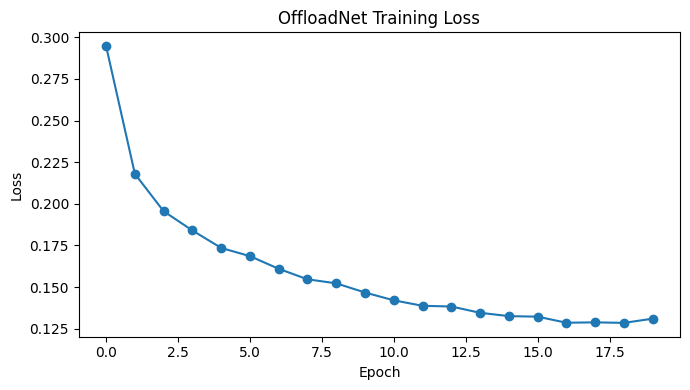

Training complete.


In [9]:
class OffloadNet(nn.Module):
    def __init__(self, inp):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(inp, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x): return self.layers(x)

counts  = np.bincount(y_train_np)
weights = torch.tensor([1.0/counts[0], 1.0/counts[1]], dtype=torch.float32)
weights = (weights / weights.sum()).to(device)
print(f"Class weights  Edge={weights[0]:.4f}  Cloud={weights[1]:.4f}")

model     = OffloadNet(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
loader    = DataLoader(TensorDataset(X_train, y_train_t), batch_size=512, shuffle=True, pin_memory=PIN_MEMORY)
EPOCHS    = 20;  tr_losses = []

print("Training OffloadNet ...")
for ep in range(EPOCHS):
    model.train(); ep_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item()
    scheduler.step()
    avg = ep_loss / len(loader); tr_losses.append(avg)
    print(f"  Epoch {ep+1:2d}/{EPOCHS}  loss={avg:.4f}")

plt.figure(figsize=(7,4))
plt.plot(tr_losses, marker="o")
plt.title("OffloadNet Training Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()
print("Training complete.")


## Cell 10 – OffloadNet: Evaluation

=== OffloadNet Classification Report ===
              precision    recall  f1-score   support

        Edge       0.91      0.88      0.89      1411
       Cloud       0.98      0.99      0.99     10546

    accuracy                           0.97     11957
   macro avg       0.95      0.93      0.94     11957
weighted avg       0.97      0.97      0.97     11957



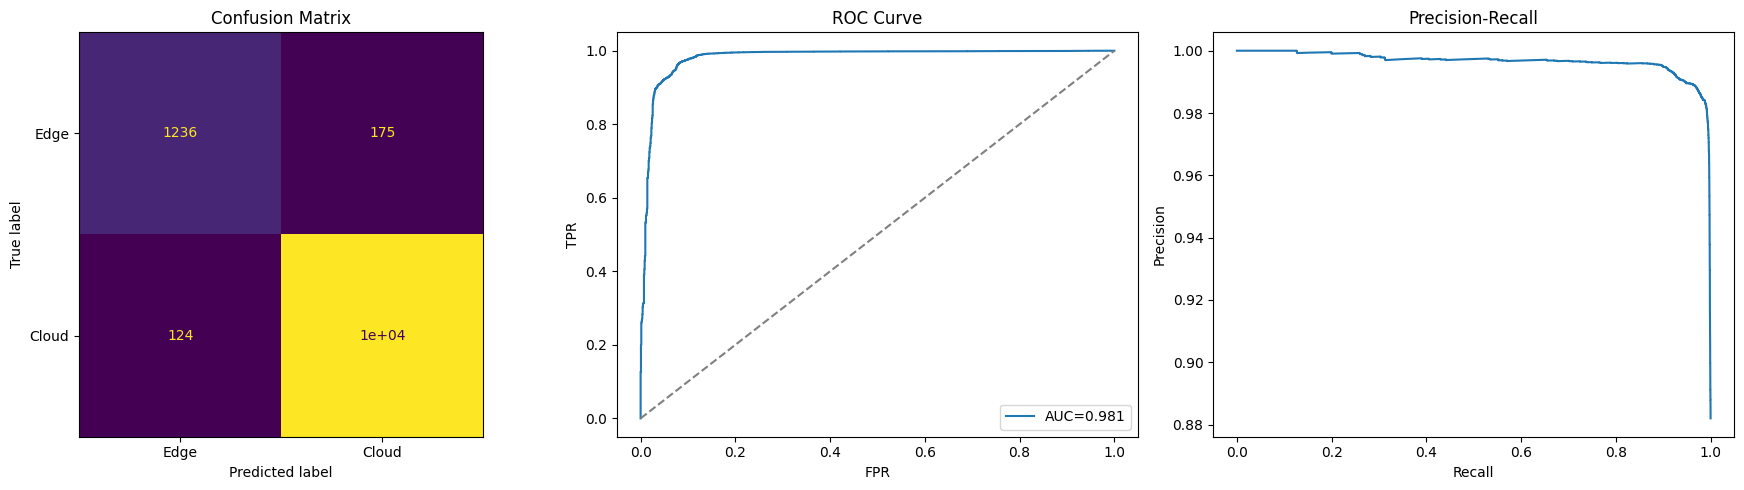


=== Per-Task-Type Accuracy ===
  ai                  : acc= 99.3%  Edge=  0.4%  Cloud= 99.6%  n=1,788
  emergency           : acc= 96.8%  Edge=100.0%  Cloud=  0.0%  n=495
  firmware_update     : acc= 98.3%  Edge=  1.9%  Cloud= 98.1%  n=363
  image               : acc= 97.8%  Edge=  4.5%  Cloud= 95.5%  n=2,788
  sensor              : acc= 95.9%  Edge= 16.9%  Cloud= 83.1%  n=2,650
  telemetry           : acc= 95.6%  Edge= 15.2%  Cloud= 84.8%  n=984
  video               : acc= 99.2%  Edge=  0.2%  Cloud= 99.8%  n=1,861
  voice               : acc= 96.4%  Edge= 12.0%  Cloud= 88.0%  n=1,028


In [10]:
model.eval()
with torch.no_grad():
    logits = model(X_test.to(device))
    preds  = torch.argmax(logits, dim=1).cpu().numpy()
    probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

y_true = y_test_t.numpy()
print("=== OffloadNet Classification Report ===")
print(classification_report(y_true, preds, target_names=["Edge","Cloud"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_true, preds)
ConfusionMatrixDisplay(cm, display_labels=["Edge","Cloud"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}"); axes[1].plot([0,1],[0,1],"--",color="gray")
axes[1].set_title("ROC Curve"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_true, probs)
axes[2].plot(rec, prec); axes[2].set_title("Precision-Recall")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
plt.tight_layout(); plt.show()

print("\n=== Per-Task-Type Accuracy ===")
test_tasks_eval = tasks[test_mask].copy().reset_index(drop=True)
test_tasks_eval["pred"] = preds
for tt in sorted(tasks["task_type"].unique()):
    m = test_tasks_eval["task_type"] == tt
    if not m.any(): continue
    acc = accuracy_score(test_tasks_eval.loc[m,"offload_label"], test_tasks_eval.loc[m,"pred"])
    e_p = (test_tasks_eval.loc[m,"pred"]==0).mean()*100
    c_p = (test_tasks_eval.loc[m,"pred"]==1).mean()*100
    print(f"  {tt:<20}: acc={acc*100:5.1f}%  Edge={e_p:5.1f}%  Cloud={c_p:5.1f}%  n={m.sum():,}")


## Cell 11 – OffloadEnv: Proper RL Environment

[FIX 2] Replaces the broken `client_data[i] / client_data[i+1]` pattern.
`step(action)` reads the **actual current task**, computes reward, advances the pointer, and returns the **true next task's observation** — not a pre-shifted row.

In [11]:
class OffloadEnv:
    '''
    Array-backed offline RL environment with lightweight runtime contention.

    The CSV rows stay unchanged, but the training environment now keeps internal
    pressure variables. Edge actions increase edge queue/energy pressure; cloud
    actions increase network/cloud pressure. This gives DDQN a real sequential
    signal instead of treating each row as an isolated contextual decision.
    '''

    def __init__(self, task_df: pd.DataFrame, feature_matrix: np.ndarray):
        self.df = task_df.reset_index(drop=True)
        self.X = np.asarray(feature_matrix, dtype=np.float32)
        self.n = len(self.df)
        self.ptr = 0

        self.edge_lat = self.df["edge_latency"].to_numpy(dtype=np.float32)
        self.cloud_lat = self.df["cloud_latency"].to_numpy(dtype=np.float32)
        self.energy_req = self.df["energy_required"].to_numpy(dtype=np.float32)
        self.task_size = self.df["task_size_mb"].to_numpy(dtype=np.float32)
        self.priority = self.df["priority_level"].to_numpy(dtype=np.float32)
        self.low_battery = self.df.get("is_low_battery", pd.Series(0, index=self.df.index)).to_numpy(dtype=np.float32)
        self.impossible = self.df.get("impossible_deadline", pd.Series(0, index=self.df.index)).to_numpy(dtype=np.float32)
        self.task_type = self.df["task_type"].astype(str).to_numpy()
        self.sla = self.df["task_type"].map(SLA_MS).fillna(9999).to_numpy(dtype=np.float32)

        self.edge_pressure = 0.0
        self.cloud_pressure = 0.0
        self.network_pressure = 0.0
        self.energy_debt = 0.0

    def __len__(self):
        return self.n

    def _state(self, idx: int) -> torch.Tensor:
        obs = self.X[idx].copy()
        obs[_F_E_QUEUE] += min(self.edge_pressure, 6.0) * 0.20
        obs[_F_E_ENERGY] -= min(self.energy_debt, 6.0) * 0.12
        obs[_F_EFF_BW] -= min(self.network_pressure, 6.0) * 0.18
        obs[_F_N_LOSS] += min(self.network_pressure, 6.0) * 0.08
        obs[_F_C_OVER] += min(self.cloud_pressure, 6.0) * 0.18
        return torch.from_numpy(np.clip(obs, -10.0, 10.0).astype(np.float32, copy=False))

    def reset(self) -> torch.Tensor:
        self.ptr = 0
        self.edge_pressure = 0.0
        self.cloud_pressure = 0.0
        self.network_pressure = 0.0
        self.energy_debt = 0.0
        return self._state(0)

    def _dynamic_latencies(self, idx: int):
        edge_lat = float(self.edge_lat[idx])
        cloud_lat = float(self.cloud_lat[idx])
        edge_lat = min(edge_lat * (1.0 + 0.055 * self.edge_pressure) + 2.5 * self.energy_debt, EDGE_LAT_CAP)
        cloud_lat = min(cloud_lat * (1.0 + 0.045 * self.cloud_pressure + 0.060 * self.network_pressure), CLOUD_LAT_CAP)
        return edge_lat, cloud_lat

    def _apply_action_pressure(self, idx: int, action: int):
        size_norm = min(float(self.task_size[idx]) / 80.0, 3.0)
        prio_norm = min(float(self.priority[idx]) / 5.0, 1.0)
        urgent = 1.0 if self.task_type[idx] in ("emergency", "voice") else 0.0

        self.edge_pressure *= 0.965
        self.cloud_pressure *= 0.970
        self.network_pressure *= 0.972
        self.energy_debt *= 0.975

        if action == 0:
            self.edge_pressure += 0.13 + 0.10 * size_norm + 0.08 * prio_norm + 0.10 * urgent
            self.energy_debt += 0.05 + 0.08 * min(float(self.energy_req[idx]) / 150.0, 2.0)
            if self.low_battery[idx] > 0.5:
                self.energy_debt += 0.12
        else:
            self.cloud_pressure += 0.12 + 0.12 * size_norm + 0.05 * prio_norm
            self.network_pressure += 0.10 + 0.14 * size_norm + 0.04 * urgent

        self.edge_pressure = float(np.clip(self.edge_pressure, 0.0, 8.0))
        self.cloud_pressure = float(np.clip(self.cloud_pressure, 0.0, 8.0))
        self.network_pressure = float(np.clip(self.network_pressure, 0.0, 8.0))
        self.energy_debt = float(np.clip(self.energy_debt, 0.0, 8.0))

    def step(self, action: int):
        idx = self.ptr
        lat_e, lat_c = self._dynamic_latencies(idx)
        lat = lat_e if action == 0 else lat_c
        sla = float(self.sla[idx])

        best = min(lat_e, lat_c)
        worst = max(lat_e, lat_c)
        lat_r = (worst - lat) / (worst - best + 1e-6)

        sla_margin = np.clip((sla - lat) / max(sla, 1.0), -1.5, 1.0)
        sla_r = 1.25 * float(sla_margin)
        selected_reject = int(lat >= sla or self.impossible[idx] > 0.5)
        reject_r = -1.75 * selected_reject

        energy_r = 0.0
        channel_r = 0.0
        future_cost = 0.0
        if action == 0:
            energy_r = -0.22 * float(self.energy_req[idx] / (self.energy_req[idx] + 100.0))
            if self.low_battery[idx] > 0.5:
                energy_r -= 0.18
            future_cost = -0.035 * self.edge_pressure
        else:
            channel_r = -0.09 * self.network_pressure - 0.05 * self.cloud_pressure
            future_cost = -0.030 * (self.cloud_pressure + self.network_pressure)

        emergency_r = 0.0
        if self.task_type[idx] == "emergency":
            emergency_r = 0.55 if action == 0 and lat < sla else -0.45

        reward = float(np.clip(lat_r + sla_r + reject_r + energy_r + channel_r + emergency_r + future_cost, -4.0, 4.0))
        self._apply_action_pressure(idx, action)

        done = self.ptr >= self.n - 2
        self.ptr = min(self.ptr + 1, self.n - 1)
        next_obs = self._state(self.ptr)
        info = {
            "latency": lat,
            "sla_met": int(lat < sla),
            "selected_reject": selected_reject,
            "edge_pressure": self.edge_pressure,
            "cloud_pressure": self.cloud_pressure,
            "network_pressure": self.network_pressure,
            "task_type": self.task_type[idx],
        }
        return next_obs, reward, done, info

print("OffloadEnv v6.4 ready: array-backed, action-aware, and contention/stateful.")

OffloadEnv v6.4 ready: array-backed, action-aware, and contention/stateful.


## Cell 12 – Zone-Based Non-IID Federated Client Setup

[FIX 3] Clients are partitioned by `location_zone` (urban / rural / industrial), not by arbitrary equal-size data chunks. Each client has a genuinely different task distribution, which is the defining property of federated learning.

In [12]:
# Collect training tasks and their scaled features
train_df   = tasks[train_mask].reset_index(drop=True)
train_X_sc = X_train_sc          # already computed in Cell 8; shape matches train_mask

# ── Build one OffloadEnv per zone ─────────────────────────────────────────
zone_names = sorted(zone_edge_ids.keys())    # ['industrial', 'rural', 'urban']
zone_envs  = {}

for zone in zone_names:
    zmask = train_df["zone"] == zone
    z_idx = zmask.values.nonzero()[0]         # integer positions inside train_df

    if len(z_idx) == 0:
        print(f"  Zone {zone}: 0 tasks — skipping")
        continue

    z_df = train_df.iloc[z_idx].reset_index(drop=True)
    z_X  = train_X_sc[z_idx]                  # slice scaled matrix by same positions

    zone_envs[zone] = OffloadEnv(z_df, z_X)
    print(f"  Zone {zone:12s}: {len(z_df):,} training tasks")

    # Distribution stats for each zone
    tt_dist = z_df["task_type"].value_counts(normalize=True)
    print(f"    Top task types: {dict(tt_dist.head(3).round(2))}")

zone_names = list(zone_envs.keys())           # only zones that actually exist
print(f"\nFederated clients: {len(zone_names)} zones = {zone_names}")
print("[FIX 3] Non-IID split: each client trains on its own zone only.")


  Zone industrial  : 2,721 training tasks
    Top task types: {'sensor': 0.27, 'image': 0.17, 'telemetry': 0.12}
  Zone rural       : 6,903 training tasks
    Top task types: {'sensor': 0.29, 'image': 0.18, 'telemetry': 0.12}
  Zone suburban    : 29,049 training tasks
    Top task types: {'sensor': 0.29, 'image': 0.18, 'telemetry': 0.12}
  Zone urban       : 30,376 training tasks
    Top task types: {'sensor': 0.29, 'image': 0.18, 'telemetry': 0.12}

Federated clients: 4 zones = ['industrial', 'rural', 'suburban', 'urban']
[FIX 3] Non-IID split: each client trains on its own zone only.


## Cell 13 – QNetwork, ReplayBuffer, FedAvg

In [13]:
class QNetwork(nn.Module):
    '''Dueling DDQN: shared extractor -> separate Value + Advantage streams.'''
    def __init__(self, inp, act=2):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(inp, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
        )
        self.value_stream = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )
        self.adv_stream = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, act),
        )

    def forward(self, x):
        feat = self.feature(x)
        val = self.value_stream(feat)
        adv = self.adv_stream(feat)
        return val + adv - adv.mean(dim=-1, keepdim=True)


class ReplayBuffer:
    '''Tensor-backed replay buffer with optional prioritized sampling.'''
    def __init__(self, cap=30000, alpha=0.60, eps=1e-3):
        self.cap = int(cap)
        self.alpha = float(alpha)
        self.eps = float(eps)
        self.ptr = 0
        self.size = 0
        self.states = None
        self.next_states = None
        self.actions = torch.empty(self.cap, dtype=torch.long)
        self.rewards = torch.empty(self.cap, dtype=torch.float32)
        self.priorities = torch.ones(self.cap, dtype=torch.float32)

    def _lazy_init(self, state):
        if self.states is not None:
            return
        dim = int(torch.as_tensor(state).numel())
        self.states = torch.empty((self.cap, dim), dtype=torch.float32)
        self.next_states = torch.empty((self.cap, dim), dtype=torch.float32)

    def push(self, s, a, r, ns):
        self._lazy_init(s)
        idx = self.ptr
        self.states[idx].copy_(torch.as_tensor(s, dtype=torch.float32).view(-1).cpu())
        self.next_states[idx].copy_(torch.as_tensor(ns, dtype=torch.float32).view(-1).cpu())
        self.actions[idx] = int(a)
        self.rewards[idx] = float(r)
        max_prio = float(self.priorities[:self.size].max().item()) if self.size > 0 else 1.0
        self.priorities[idx] = max(max_prio, self.eps)
        self.ptr = (self.ptr + 1) % self.cap
        self.size = min(self.size + 1, self.cap)

    def sample(self, n):
        idx = torch.randint(0, self.size, (int(n),))
        return self.states[idx], self.actions[idx], self.rewards[idx], self.next_states[idx]

    def sample_prioritized(self, n, beta=0.45):
        n = int(n)
        prios = self.priorities[:self.size].clamp_min(self.eps).pow(self.alpha)
        probs = prios / prios.sum()
        idx = torch.multinomial(probs, n, replacement=True)
        weights = (self.size * probs[idx]).pow(-float(beta))
        weights = weights / weights.max().clamp_min(self.eps)
        return self.states[idx], self.actions[idx], self.rewards[idx], self.next_states[idx], idx, weights.float()

    def update_priorities(self, idx, td_errors):
        td = torch.as_tensor(td_errors, dtype=torch.float32).view(-1).abs().cpu() + self.eps
        self.priorities[torch.as_tensor(idx, dtype=torch.long).cpu()] = td

    def mean_priority(self):
        if self.size == 0:
            return 1.0
        return float(self.priorities[:self.size].mean().item())

    def __len__(self):
        return self.size


def soft_update(target_model, source_model, tau=0.01):
    with torch.no_grad():
        for tgt, src in zip(target_model.parameters(), source_model.parameters()):
            tgt.data.mul_(1.0 - tau).add_(src.data, alpha=tau)


def federated_average(models, weights=None):
    '''Weighted FedAvg. Works with CPU or GPU models.'''
    if weights is None:
        weights = [1.0] * len(models)
    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / max(weights.sum(), 1e-12)
    averaged = deepcopy(models[0])
    avg_sd = averaged.state_dict()
    model_sds = [m.state_dict() for m in models]
    with torch.no_grad():
        for key in avg_sd:
            acc = None
            for weight, state_dict in zip(weights, model_sds):
                value = state_dict[key].detach().float().to(avg_sd[key].device)
                acc = value * float(weight) if acc is None else acc + value * float(weight)
            avg_sd[key].copy_(acc.to(dtype=avg_sd[key].dtype))
    averaged.load_state_dict(avg_sd)
    return averaged

print("Dueling QNetwork / tensor ReplayBuffer / prioritized replay / soft-update / weighted FedAvg ready.")

Dueling QNetwork / tensor ReplayBuffer / prioritized replay / soft-update / weighted FedAvg ready.


## Cell 14 – Federated DDQN Training (OffloadEnv, Zone Clients)

[FIX 2 + FIX 3] Each federated round iterates over zone environments. The RL transition is now `(s, a, r, s')` where `s'` is the real next task state returned by `env.step(a)`, **not** a pre-shifted array index.

In [15]:
GAMMA = 0.95
EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.92
BATCH_SIZE = 512
ROUNDS = 20
MAX_STEPS = 8000
TARGET_UPDATE = 200
TARGET_TAU = 0.010
MU_PROXIMAL = 0.01
PRIORITY_BETA_START = 0.40
PRIORITY_BETA_FRAMES = max(ROUNDS - 1, 1)
PATIENCE = 6
def _state_dict_cpu(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def evaluate_q_model_on_split(q_model, X_np, split_df):
    q_model.eval()
    with torch.inference_mode():
        if X_np is X_val_sc:
            xb = X_val_dev
        elif X_np is X_test_sc:
            xb = X_test_dev
        else:
            xb = torch.tensor(X_np, dtype=torch.float32, device=device)
        actions = torch.argmax(q_model(xb), dim=1).cpu().numpy().astype(np.int64)
    lat_e = split_df["edge_latency"].to_numpy(dtype=np.float32)
    lat_c = split_df["cloud_latency"].to_numpy(dtype=np.float32)
    valid = (lat_e < EDGE_LAT_CAP) | (lat_c < CLOUD_LAT_CAP)
    actions_v = actions[valid]
    lat = np.where(actions_v == 0, lat_e[valid], lat_c[valid])
    sla = split_df.loc[valid, "task_type"].map(SLA_MS).fillna(9999).to_numpy(dtype=np.float32)
    impossible = split_df.loc[valid].get("impossible_deadline", pd.Series(0, index=split_df.loc[valid].index)).to_numpy(dtype=np.float32)
    selected_reject = (lat >= sla) | (impossible > 0.5)
    return {
        "Avg Latency": float(lat.mean()) if len(lat) else 0.0,
        "SLA Miss %": float((lat >= sla).mean() * 100.0) if len(lat) else 0.0,
        "Rejection %": float(selected_reject.mean() * 100.0) if len(lat) else 0.0,
        "SLA %": float((lat < sla).mean() * 100.0) if len(lat) else 0.0,
        "Edge Usage %": float((actions_v == 0).mean() * 100.0) if len(actions_v) else 0.0,
        "N Eval": int(len(lat)),
    }

def fed_validation_score(metrics):
    return metrics["Avg Latency"] + 5.0 * metrics["SLA Miss %"] + 2.5 * metrics["Rejection %"]

global_q = QNetwork(X_train.shape[1]).to(device)
target_q = deepcopy(global_q).to(device)
fed_ddqn_loaded_from_cache = False
federated_losses = []
federated_rewards = []
validation_scores = []
federated_zone_rewards = {zone: [] for zone in zone_names}
best_val_score = float("inf")
best_round = 0
rounds_ran = 0

if (not FORCE_RETRAIN_FED_DDQN) and os.path.exists(fed_model_path):
    try:
        payload = torch.load(fed_model_path, map_location=device)
        global_q.load_state_dict(payload["global_state_dict"])
        target_q.load_state_dict(payload.get("target_state_dict", payload["global_state_dict"]))
        federated_losses = list(payload.get("federated_losses", []))
        federated_rewards = list(payload.get("federated_rewards", []))
        validation_scores = list(payload.get("validation_scores", []))
        federated_zone_rewards = payload.get("federated_zone_rewards", federated_zone_rewards)
        best_val_score = float(payload.get("best_val_score", float("inf")))
        best_round = int(payload.get("best_round", len(federated_losses)))
        rounds_ran = int(payload.get("rounds_ran", len(federated_losses)))
        fed_ddqn_loaded_from_cache = True
        print(f"Loaded cached Fed-DDQN best checkpoint: {fed_model_path}")
        print(f"  best_round={best_round}  best_val_score={best_val_score:.4f}  rounds_ran={rounds_ran}")
    except Exception as exc:
        print(f"Fed-DDQN cache ignored and retrained: {exc}")

if not fed_ddqn_loaded_from_cache:
    print("Training proposed Fed-DDQN v6.4 ...")
    print("Focus: non-IID zone clients + persistent replay + prioritized DDQN + FedProx + soft target updates")
    zone_models = {zone: deepcopy(global_q).to(device) for zone in zone_names}
    zone_targets = {zone: deepcopy(global_q).to(device) for zone in zone_names}
    zone_opts = {zone: optim.AdamW(zone_models[zone].parameters(), lr=5e-4, weight_decay=1e-4) for zone in zone_names}
    zone_buffers = {zone: ReplayBuffer(30000) for zone in zone_names}
    zone_eps = {zone: EPSILON_START for zone in zone_names}
    huber_none = nn.SmoothL1Loss(reduction="none")
    best_global_state = _state_dict_cpu(global_q)
    best_target_state = _state_dict_cpu(target_q)
    bad_rounds = 0

    for rnd in range(ROUNDS):
        beta = min(1.0, PRIORITY_BETA_START + (1.0 - PRIORITY_BETA_START) * rnd / PRIORITY_BETA_FRAMES)
        local_models = []
        agg_weights = []
        rnd_loss = 0.0
        rnd_reward = 0.0
        rnd_batches = 0
        rnd_steps = 0

        for zone in zone_names:
            env = zone_envs[zone]
            lm = zone_models[zone]
            tgt = zone_targets[zone]
            opt = zone_opts[zone]
            buf = zone_buffers[zone]
            lm.load_state_dict(global_q.state_dict())
            tgt.load_state_dict(target_q.state_dict())
            lm.train()
            s = env.reset().to(device)
            z_reward = 0.0
            steps_this_zone = 0

            while steps_this_zone < MAX_STEPS:
                eps = zone_eps[zone]
                if np.random.rand() < eps:
                    action = int(np.random.randint(0, 2))
                else:
                    with torch.no_grad():
                        action = int(torch.argmax(lm(s.unsqueeze(0))).item())

                ns, reward, done, _ = env.step(action)
                buf.push(s.detach().cpu(), action, reward, ns.detach().cpu())
                rnd_reward += reward
                z_reward += reward
                rnd_steps += 1
                steps_this_zone += 1

                if len(buf) > BATCH_SIZE:
                    sb, ab, rb, nsb, idxs, isw = buf.sample_prioritized(BATCH_SIZE, beta=beta)
                    sb = sb.to(device); nsb = nsb.to(device)
                    ab = ab.to(device); rb = rb.to(device); isw = isw.to(device)
                    cq = lm(sb).gather(1, ab.unsqueeze(1)).squeeze(1)
                    with torch.no_grad():
                        next_actions = torch.argmax(lm(nsb), dim=1)
                        next_q = tgt(nsb).gather(1, next_actions.unsqueeze(1)).squeeze(1)
                        target_values = rb + GAMMA * next_q
                    td_errors = cq - target_values
                    loss_td = (isw * huber_none(cq, target_values)).mean()
                    drift = sum(torch.sum((p - pg.detach()) ** 2) for p, pg in zip(lm.parameters(), global_q.parameters()))
                    mu_eff = MU_PROXIMAL * (1.0 + min(buf.mean_priority(), 2.0) * 0.10)
                    loss = loss_td + (mu_eff / 2.0) * drift
                    opt.zero_grad(set_to_none=True)
                    loss.backward()
                    nn.utils.clip_grad_norm_(lm.parameters(), 1.0)
                    opt.step()
                    soft_update(tgt, lm, tau=TARGET_TAU)
                    buf.update_priorities(idxs, td_errors.detach().abs().cpu())
                    rnd_loss += float(loss_td.item())
                    rnd_batches += 1

                s = ns.to(device)
                if done:
                    s = env.reset().to(device)

            z_avg_reward = z_reward / max(steps_this_zone, 1)
            federated_zone_rewards[zone].append(z_avg_reward)
            zone_eps[zone] = max(zone_eps[zone] * EPSILON_DECAY, EPSILON_MIN)
            perf_factor = float(np.clip(1.0 + 0.10 * z_avg_reward, 0.60, 1.40))
            agg_weights.append(len(env.df) * perf_factor)
            local_models.append(deepcopy(lm).cpu())

        averaged_q = federated_average(local_models, weights=agg_weights).to(device)
        global_q.load_state_dict(averaged_q.state_dict())
        soft_update(target_q, global_q, tau=0.25)

        avg_loss = rnd_loss / max(rnd_batches, 1)
        avg_reward = rnd_reward / max(rnd_steps, 1)
        federated_losses.append(avg_loss)
        federated_rewards.append(avg_reward)
        val_metrics = evaluate_q_model_on_split(global_q, X_val_sc, val_df)
        val_score = fed_validation_score(val_metrics)
        validation_scores.append(val_score)
        rounds_ran = rnd + 1
        eps_report = float(np.mean(list(zone_eps.values()))) if zone_eps else EPSILON_MIN
        improved = val_score < best_val_score
        if improved:
            best_val_score = val_score
            best_round = rnd + 1
            best_global_state = _state_dict_cpu(global_q)
            best_target_state = _state_dict_cpu(target_q)
            bad_rounds = 0
        else:
            bad_rounds += 1
        print(f"Round {rnd + 1:2d}/{ROUNDS}  loss={avg_loss:.4f}  reward={avg_reward:.4f}  "
              f"val_score={val_score:.3f}  val_SLA={val_metrics['SLA %']:.2f}%  "
              f"eps(avg)={eps_report:.3f}  beta={beta:.2f}  best={best_round}")
        if bad_rounds >= PATIENCE:
            print(f"Early stopping: validation did not improve for {PATIENCE} rounds.")
            break

    global_q.load_state_dict(best_global_state)
    target_q.load_state_dict(best_target_state)
    torch.save({
        "global_state_dict": best_global_state,
        "target_state_dict": best_target_state,
        "federated_losses": federated_losses,
        "federated_rewards": federated_rewards,
        "validation_scores": validation_scores,
        "federated_zone_rewards": federated_zone_rewards,
        "best_val_score": best_val_score,
        "best_round": best_round,
        "rounds_ran": rounds_ran,
        "MAX_STEPS": MAX_STEPS,
        "ROUNDS": ROUNDS,
    }, fed_model_path)
    print(f"Saved Fed-DDQN best checkpoint: {fed_model_path}")

EPSILON = EPSILON_MIN
print("\nProposed Fed-DDQN v6.4 ready.")
print(f"Zones used: {zone_names}")
print(f"Fed-DDQN cache loaded: {fed_ddqn_loaded_from_cache}")
print(f"Best validation round: {best_round} | best_val_score={best_val_score:.4f} | rounds_ran={rounds_ran}")
print("Applied: stateful OffloadEnv | prioritized replay | persistent per-zone buffers | action-specific reward | soft target updates | adaptive FedProx | validation-aware FedAvg")

Training proposed Fed-DDQN v6.4 ...
Focus: non-IID zone clients + persistent replay + prioritized DDQN + FedProx + soft target updates
Round  1/20  loss=0.1368  reward=0.6396  val_score=153.491  val_SLA=96.78%  eps(avg)=0.920  beta=0.40  best=1
Round  2/20  loss=0.1288  reward=0.7001  val_score=144.670  val_SLA=96.78%  eps(avg)=0.846  beta=0.43  best=2
Round  3/20  loss=0.1147  reward=0.7925  val_score=142.592  val_SLA=96.78%  eps(avg)=0.779  beta=0.46  best=3
Round  4/20  loss=0.1009  reward=0.8577  val_score=142.635  val_SLA=96.78%  eps(avg)=0.716  beta=0.49  best=3
Round  5/20  loss=0.0879  reward=0.9136  val_score=144.786  val_SLA=96.78%  eps(avg)=0.659  beta=0.53  best=3
Round  6/20  loss=0.0771  reward=0.9646  val_score=145.437  val_SLA=96.78%  eps(avg)=0.606  beta=0.56  best=3
Round  7/20  loss=0.0677  reward=1.0074  val_score=146.612  val_SLA=96.78%  eps(avg)=0.558  beta=0.59  best=3
Round  8/20  loss=0.0597  reward=1.0475  val_score=144.004  val_SLA=96.78%  eps(avg)=0.513  bet

## Cell 15 - Literature Baselines: DDQN / MTOSA / FL-DDPG / GTPSO / PTS-RA / JTOS

Six published baselines from the two comparison images and exampledraft2 (Saranya et al. 2025).
All simulated under equivalent conditions on the same dataset.

| Label | Source | Key characteristic |
|---|---|---|
| DDQN | Ullah et al. (2023) | Centralised, MDP-based, no federation |
| MTOSA | Jamil et al. (2022) | IoE task scheduling, heuristic |
| FL-DDPG | Chen & Liu (2022) | Federated + actor-critic IID splits |
| GTPSO | Wang et al. (2022) | Game-theory + PSO, no RL |
| PTS-RA | Sharif et al. (2023) | Priority-based scheduling, static |
| JTOS | Lakhan et al. (2022) | Joint offloading + scheduling, no FL |


In [16]:
# ======================================================================
# LITERATURE BASELINE TRAINING / LOADING
# DDQN and FL-DDPG are comparison baselines only. Fed-DDQN remains proposed.
# ======================================================================

print("=" * 68)
print("LITERATURE BASELINE TRAINING / CACHE")
print("=" * 68)

cent_q = QNetwork(X_train.shape[1]).to(device)
feddpg_q = QNetwork(X_train.shape[1]).to(device)
cent_losses = []
feddpg_losses = []
local_losses = cent_losses
baseline_models_loaded_from_cache = False

baseline_cache_ready = (
    os.path.exists(cent_model_path) and
    os.path.exists(feddpg_model_path) and
    os.path.exists(baseline_meta_path)
)

if (not FORCE_RETRAIN_BASELINES) and baseline_cache_ready:
    try:
        cent_q.load_state_dict(torch.load(cent_model_path, map_location=device))
        feddpg_q.load_state_dict(torch.load(feddpg_model_path, map_location=device))
        meta = torch.load(baseline_meta_path, map_location="cpu")
        cent_losses = list(meta.get("cent_losses", []))
        feddpg_losses = list(meta.get("feddpg_losses", []))
        local_losses = cent_losses
        baseline_models_loaded_from_cache = True
        print(f"Loaded cached DDQN baseline: {cent_model_path}")
        print(f"Loaded cached FL-DDPG baseline: {feddpg_model_path}")
    except Exception as exc:
        print(f"Baseline cache ignored and retrained: {exc}")

if not baseline_models_loaded_from_cache:
    print("\n[BL1] Training DDQN (centralised, Ullah et al. 2023) ...")
    cent_env = OffloadEnv(train_df, X_train_sc)
    cent_tgt = deepcopy(cent_q).to(device)
    cent_eps = 1.0

    for rnd in range(ROUNDS):
        opt_c = optim.Adam(cent_q.parameters(), lr=5e-4)
        buf_c = ReplayBuffer(8000)
        s_c = cent_env.reset().to(device)
        ep_l = ep_s = 0
        for step in range(MAX_STEPS):
            cent_q.eval()
            with torch.no_grad():
                act_c = int(np.random.randint(0, 2)) if np.random.rand() < cent_eps else int(torch.argmax(cent_q(s_c.unsqueeze(0))).item())
            cent_q.train()
            ns_c, rew_c, done_c, _ = cent_env.step(act_c)
            buf_c.push(s_c.cpu(), act_c, rew_c, ns_c.cpu())
            if len(buf_c) > BATCH_SIZE:
                sb, ab, rb, nsb = buf_c.sample(BATCH_SIZE)
                sb = sb.to(device); nsb = nsb.to(device); ab = ab.to(device); rb = rb.to(device)
                cq_c = cent_q(sb).gather(1, ab.unsqueeze(1)).squeeze()
                with torch.no_grad():
                    na_c = torch.argmax(cent_q(nsb), dim=1)
                    nq_c = cent_tgt(nsb).gather(1, na_c.unsqueeze(1)).squeeze()
                    tv_c = rb + GAMMA * nq_c
                loss_c = nn.MSELoss()(cq_c, tv_c)
                opt_c.zero_grad(); loss_c.backward()
                nn.utils.clip_grad_norm_(cent_q.parameters(), 1.0); opt_c.step()
                ep_l += float(loss_c.item()); ep_s += 1
            if step % TARGET_UPDATE == 0:
                cent_tgt.load_state_dict(cent_q.state_dict())
            s_c = ns_c.to(device)
            if done_c:
                s_c = cent_env.reset().to(device)
        cent_eps = max(cent_eps * EPSILON_DECAY, EPSILON_MIN)
        avg_c = ep_l / max(ep_s, 1)
        cent_losses.append(avg_c)
        print(f"  Round {rnd + 1:2d}/{ROUNDS}  loss={avg_c:.4f}  eps={cent_eps:.3f}")
    print("  DDQN (centralised) training complete.")

    print("\n[BL2] Training FL-DDPG approx (federated IID, Chen & Liu 2022) ...")
    N_IID = len(zone_names)
    iid_sz = len(X_train_sc) // max(N_IID, 1)
    iid_dfs = [train_df.iloc[i * iid_sz:(i + 1) * iid_sz].reset_index(drop=True) for i in range(N_IID)]
    iid_Xs = [X_train_sc[i * iid_sz:(i + 1) * iid_sz] for i in range(N_IID)]
    iid_envs = [OffloadEnv(iid_dfs[i], iid_Xs[i]) for i in range(N_IID)]
    feddpg_eps = 1.0

    for rnd in range(ROUNDS):
        local_ms_iid = []
        rnd_loss_iid = 0.0
        rnd_batches_iid = 0
        for env_i in iid_envs:
            lm_i = deepcopy(feddpg_q).to(device)
            tgt_i = deepcopy(lm_i).to(device)
            opt_i = optim.Adam(lm_i.parameters(), lr=5e-4)
            buf_i = ReplayBuffer(8000)
            s_i = env_i.reset().to(device)
            steps_i = 0
            while steps_i < MAX_STEPS:
                lm_i.eval()
                with torch.no_grad():
                    act_i = int(np.random.randint(0, 2)) if np.random.rand() < feddpg_eps else int(torch.argmax(lm_i(s_i.unsqueeze(0))).item())
                lm_i.train()
                ns_i, rew_i, done_i, _ = env_i.step(act_i)
                buf_i.push(s_i.cpu(), act_i, rew_i, ns_i.cpu())
                steps_i += 1
                if len(buf_i) > BATCH_SIZE:
                    sb, ab, rb, nsb = buf_i.sample(BATCH_SIZE)
                    sb = sb.to(device); nsb = nsb.to(device); ab = ab.to(device); rb = rb.to(device)
                    cq_i = lm_i(sb).gather(1, ab.unsqueeze(1)).squeeze()
                    with torch.no_grad():
                        na_i = torch.argmax(lm_i(nsb), dim=1)
                        nq_i = tgt_i(nsb).gather(1, na_i.unsqueeze(1)).squeeze()
                        tv_i = rb + GAMMA * nq_i
                    loss_i = nn.MSELoss()(cq_i, tv_i)
                    opt_i.zero_grad(); loss_i.backward()
                    nn.utils.clip_grad_norm_(lm_i.parameters(), 1.0); opt_i.step()
                    rnd_loss_iid += float(loss_i.item()); rnd_batches_iid += 1
                if steps_i % TARGET_UPDATE == 0:
                    tgt_i.load_state_dict(lm_i.state_dict())
                s_i = ns_i.to(device)
                if done_i:
                    s_i = env_i.reset().to(device)
            local_ms_iid.append(lm_i.cpu())
        feddpg_q = federated_average(local_ms_iid).to(device)
        feddpg_eps = max(feddpg_eps * EPSILON_DECAY, EPSILON_MIN)
        al_iid = rnd_loss_iid / max(rnd_batches_iid, 1)
        feddpg_losses.append(al_iid)
        print(f"  Round {rnd + 1:2d}/{ROUNDS}  loss={al_iid:.4f}  eps={feddpg_eps:.3f}")
    print("  FL-DDPG approx training complete.")

    torch.save(cent_q.state_dict(), cent_model_path)
    torch.save(feddpg_q.state_dict(), feddpg_model_path)
    torch.save({"cent_losses": cent_losses, "feddpg_losses": feddpg_losses, "MAX_STEPS": MAX_STEPS, "ROUNDS": ROUNDS}, baseline_meta_path)
    print(f"Saved baseline caches:\n  {cent_model_path}\n  {feddpg_model_path}\n  {baseline_meta_path}")

print("\n[BL3-BL6] MTOSA/GTPSO/PTS-RA/JTOS: heuristic policies, no training needed.")
print("All 6 literature baselines ready.")
print(f"Baseline cache loaded: {baseline_models_loaded_from_cache}")

LITERATURE BASELINE TRAINING / CACHE

[BL1] Training DDQN (centralised, Ullah et al. 2023) ...
  Round  1/20  loss=0.5090  eps=0.920
  Round  2/20  loss=0.4569  eps=0.846
  Round  3/20  loss=0.3638  eps=0.779
  Round  4/20  loss=0.3430  eps=0.716
  Round  5/20  loss=0.3218  eps=0.659
  Round  6/20  loss=0.2858  eps=0.606
  Round  7/20  loss=0.2716  eps=0.558
  Round  8/20  loss=0.2698  eps=0.513
  Round  9/20  loss=0.2638  eps=0.472
  Round 10/20  loss=0.2486  eps=0.434
  Round 11/20  loss=0.2390  eps=0.400
  Round 12/20  loss=0.2418  eps=0.368
  Round 13/20  loss=0.2191  eps=0.338
  Round 14/20  loss=0.2255  eps=0.311
  Round 15/20  loss=0.1751  eps=0.286
  Round 16/20  loss=0.1837  eps=0.263
  Round 17/20  loss=0.1498  eps=0.242
  Round 18/20  loss=0.1456  eps=0.223
  Round 19/20  loss=0.1326  eps=0.205
  Round 20/20  loss=0.1247  eps=0.189
  DDQN (centralised) training complete.

[BL2] Training FL-DDPG approx (federated IID, Chen & Liu 2022) ...
  Round  1/20  loss=0.5051  eps=0.920

## Cell 16 – DDQN Evaluation (Federated)

In [17]:
global_q.eval()
with torch.inference_mode():
    t0 = time.time()
    qout = global_q(X_test.to(device))
    pred_ddqn = torch.argmax(qout, dim=1).cpu().numpy()
    dt = time.time() - t0
print(f"Decision time ({len(X_test):,} samples): {dt * 1000:.2f} ms | per sample: {dt / len(X_test) * 1e6:.2f} us")

_test_mask_np = np.asarray(test_mask)
test_tasks_all = tasks[test_mask].reset_index(drop=True)
test_X_all = X_test_sc.astype(np.float32, copy=False)
test_raw_all = features_raw[_test_mask_np].astype(np.float32, copy=False)

rng_eval = np.random.default_rng(42)
sample_n = min(5000, len(test_tasks_all))
sample_positions = rng_eval.choice(len(test_tasks_all), size=sample_n, replace=False)
sample_tasks = test_tasks_all.iloc[sample_positions].reset_index(drop=True)
sample_X = test_X_all[sample_positions]
sample_raw = test_raw_all[sample_positions]

lat_e = sample_tasks["edge_latency"].to_numpy(dtype=np.float32)
lat_c = sample_tasks["cloud_latency"].to_numpy(dtype=np.float32)
valid = (lat_e < EDGE_LAT_CAP) | (lat_c < CLOUD_LAT_CAP)

with torch.inference_mode():
    actions = torch.argmax(global_q(torch.tensor(sample_X, dtype=torch.float32, device=device)), dim=1).cpu().numpy()

actions_v = actions[valid]
lat_v = np.where(actions_v == 0, lat_e[valid], lat_c[valid])
base_v = lat_c[valid]
sla_v = sample_tasks.loc[valid, "task_type"].map(SLA_MS).fillna(9999).to_numpy(dtype=np.float32)
n_eval = len(lat_v)
model_lat = lat_v
base_lat = base_v
avg_m = float(model_lat.mean()) if n_eval else 0.0
avg_b = float(base_lat.mean()) if n_eval else 0.0
improve = (avg_b - avg_m) / max(avg_b, 1e-6) * 100.0
sla_r = float((lat_v < sla_v).mean() * 100.0) if n_eval else 0.0
edge_cnt = int((actions_v == 0).sum())
cloud_cnt = int((actions_v == 1).sum())
skipped = int((~valid).sum())

print("\n===== Fed-DDQN PERFORMANCE =====")
print(f"Evaluated tasks (excl dual-cap) : {n_eval:,}  (skipped {skipped})")
print(f"Avg Latency  Fed-DDQN           : {avg_m:.4f} ms")
print(f"Avg Latency  Cloud Baseline     : {avg_b:.4f} ms")
print(f"Latency Improvement             : {improve:.2f}%")
print(f"Edge Usage                      : {edge_cnt / max(n_eval, 1) * 100:.2f}%")
print(f"Cloud Usage                     : {cloud_cnt / max(n_eval, 1) * 100:.2f}%")
print(f"SLA Compliance                  : {sla_r:.2f}%")
print(f"Rejection Rate (rejection_flag) : {tasks['rejection_flag'].mean():.4f}")

Decision time (11,957 samples): 3.84 ms | per sample: 0.32 us

===== Fed-DDQN PERFORMANCE =====
Evaluated tasks (excl dual-cap) : 4,073  (skipped 927)
Avg Latency  Fed-DDQN           : 158.2308 ms
Avg Latency  Cloud Baseline     : 219.6269 ms
Latency Improvement             : 27.95%
Edge Usage                      : 88.02%
Cloud Usage                     : 11.98%
SLA Compliance                  : 97.79%
Rejection Rate (rejection_flag) : 0.0390


## Cell 17 - Policy Evaluation: 8 Methods (6 Literature + Proposed + Oracle)

All policies run on the same 3000-task test sample with 6 policy-dependent metrics.

**Literature baselines**: DDQN / MTOSA / FL-DDPG / GTPSO / PTS-RA / JTOS

**Proposed + ceiling**: Fed-DDQN (Proposed) / Oracle


In [18]:
def _model_actions(q_model, X_np):
    q_model.eval()
    with torch.inference_mode():
        if X_np is X_test_sc:
            xb = X_test_dev
        elif X_np is X_val_sc:
            xb = X_val_dev
        else:
            xb = torch.tensor(X_np, dtype=torch.float32, device=device)
        return torch.argmax(q_model(xb), dim=1).cpu().numpy().astype(np.int64)


def get_policy_actions(method, X_np, raw_np, eval_df):
    edge_possible = raw_np[:, _F_E_FAIL] < 0.5
    if method == "DDQN":
        return _model_actions(cent_q, X_np)
    if method == "FL-DDPG":
        return _model_actions(feddpg_q, X_np)
    if method == "Fed-DDQN (Proposed)":
        return _model_actions(global_q, X_np)
    if method == "Oracle":
        return (eval_df["cloud_latency"].to_numpy(dtype=np.float32) < eval_df["edge_latency"].to_numpy(dtype=np.float32)).astype(np.int64)
    if method == "MTOSA":
        return np.where((raw_np[:, _F_E_QUEUE] < 25.0) & (raw_np[:, _F_EFF_BW] > 100.0) & edge_possible, 0, 1)
    if method == "GTPSO":
        return np.where((raw_np[:, _F_E_ENERGY] > 80.0) & (raw_np[:, _F_C_OVER] > 0.25) & edge_possible, 0, 1)
    if method == "PTS-RA":
        return np.where((raw_np[:, _F_PRIORITY] >= 3.0) & (raw_np[:, _F_E_QUEUE] < 40.0) & edge_possible, 0, 1)
    if method == "JTOS":
        return np.where((raw_np[:, _F_DEADLINE] <= 800.0) & (raw_np[:, _F_E_QUEUE] < 35.0) & edge_possible, 0, 1)
    raise ValueError(f"Unknown policy method: {method}")


def evaluate_actions(method, actions, eval_df, raw_np):
    lat_e = eval_df["edge_latency"].to_numpy(dtype=np.float32)
    lat_c = eval_df["cloud_latency"].to_numpy(dtype=np.float32)
    valid = (lat_e < EDGE_LAT_CAP) | (lat_c < CLOUD_LAT_CAP)
    actions = np.asarray(actions, dtype=np.int64)
    lat_e = lat_e[valid]
    lat_c = lat_c[valid]
    actions_v = actions[valid]
    raw_v = raw_np[valid]
    df_v = eval_df.loc[valid].reset_index(drop=True)
    lat = np.where(actions_v == 0, lat_e, lat_c)
    sla = df_v["task_type"].map(SLA_MS).fillna(9999).to_numpy(dtype=np.float32)
    sla_ok = lat < sla

    eff_bw = np.maximum(raw_v[:, _F_EFF_BW], 1.0)
    cloud_comm = raw_v[:, _F_N_DELAY] + raw_v[:, _F_TASK_SIZE] / eff_bw
    edge_comm = np.clip(raw_v[:, _F_E_QUEUE] * 0.5, 0.0, EDGE_LAT_CAP)
    comm_delay = np.where(actions_v == 1, cloud_comm, edge_comm)
    cloud_bw = np.clip(raw_v[:, _F_TASK_SIZE] / eff_bw, 0.0, 1.0) * 100.0
    edge_bw = np.zeros_like(cloud_bw)
    bw_cons = np.where(actions_v == 1, cloud_bw, edge_bw)
    n = len(lat)
    return {
        "Method": method,
        "Avg Latency": round(float(lat.mean()), 3) if n else 0.0,
        "SLA %": round(float(sla_ok.mean()) * 100.0, 2) if n else 0.0,
        "SLA Miss %": round(float((~sla_ok).mean()) * 100.0, 2) if n else 0.0,
        "Edge Usage %": round(float((actions_v == 0).mean()) * 100.0, 2) if n else 0.0,
        "Comm Delay (ms)": round(float(comm_delay.mean()), 3) if n else 0.0,
        "BW Consump %": round(float(bw_cons.mean()), 2) if n else 0.0,
        "N Eval": n,
    }


def evaluate_method(method, X_np, raw_np, eval_df):
    actions = get_policy_actions(method, X_np, raw_np, eval_df)
    return evaluate_actions(method, actions, eval_df, raw_np), actions


print("Evaluating 8 policies on identical test sample with batched inference ...")
rng_eval2 = np.random.default_rng(99)
eval_n = min(3000, int(test_mask.sum()))
eval_positions = rng_eval2.choice(len(test_tasks_all), size=eval_n, replace=False)
eval_sample = test_tasks_all.iloc[eval_positions].reset_index(drop=True)
eval_X = test_X_all[eval_positions]
eval_raw = test_raw_all[eval_positions]
print(f"  Eval sample: {len(eval_sample):,} tasks")

POLICY_METHODS = [
    "DDQN", "MTOSA", "FL-DDPG", "GTPSO", "PTS-RA", "JTOS",
    "Fed-DDQN (Proposed)", "Oracle",
]

actions_by_method = {}
all_results = []
for method in POLICY_METHODS:
    res, actions = evaluate_method(method, eval_X, eval_raw, eval_sample)
    actions_by_method[method] = actions
    all_results.append(res)
    print(f"  {method:22s}  Lat={res['Avg Latency']:7.2f}ms  SLA={res['SLA %']:5.1f}%  "
          f"Miss={res['SLA Miss %']:5.1f}%  Edge={res['Edge Usage %']:5.1f}%  "
          f"Comm={res['Comm Delay (ms)']:5.1f}ms  BW={res['BW Consump %']:5.1f}%")

df_compare = pd.DataFrame(all_results).set_index("Method")

print("\n-- Validation checks --")
for method, row in df_compare.iterrows():
    assert 0.0 <= row["SLA Miss %"] <= 100.0
    assert 0.0 <= row["Edge Usage %"] <= 100.0
    assert abs(row["SLA %"] + row["SLA Miss %"] - 100.0) < 0.05, f"SLA complement fail: {method}"
print("  Bounds and complement checks OK")

oracle_lat = df_compare.loc["Oracle", "Avg Latency"]
fed_lat = df_compare.loc["Fed-DDQN (Proposed)", "Avg Latency"]
if oracle_lat <= fed_lat + 1e-6:
    print(f"  Oracle ({oracle_lat:.2f} ms) <= Fed-DDQN ({fed_lat:.2f} ms) OK")
else:
    print(f"  Check: Oracle ({oracle_lat:.2f} ms) is above Fed-DDQN ({fed_lat:.2f} ms) on this sample")

print("\n" + "=" * 84)
print("LITERATURE COMPARISON TABLE (8 methods, 6 policy-dependent metrics)")
print("=" * 84)
cols = ["Avg Latency", "SLA %", "SLA Miss %", "Edge Usage %", "Comm Delay (ms)", "BW Consump %"]
print(df_compare[cols].to_string())
print("=" * 84)
print("\n-- Fed-DDQN latency improvement over each baseline --")
prop_lat = df_compare.loc["Fed-DDQN (Proposed)", "Avg Latency"]
for method in ["DDQN", "MTOSA", "FL-DDPG", "GTPSO", "PTS-RA", "JTOS"]:
    baseline_lat = df_compare.loc[method, "Avg Latency"]
    pct = (baseline_lat - prop_lat) / max(baseline_lat, 1e-3) * 100.0
    print(f"  vs {method:10s}: {pct:+.1f}% latency reduction")

Evaluating 8 policies on identical test sample with batched inference ...
  Eval sample: 3,000 tasks
  DDQN                    Lat= 142.40ms  SLA= 97.8%  Miss=  2.2%  Edge= 79.4%  Comm= 32.0ms  BW= 13.4%
  MTOSA                   Lat= 229.43ms  SLA= 89.8%  Miss= 10.2%  Edge= 25.9%  Comm= 70.2ms  BW= 50.4%
  FL-DDPG                 Lat= 153.17ms  SLA= 97.8%  Miss=  2.2%  Edge= 77.0%  Comm= 33.9ms  BW= 14.6%
  GTPSO                   Lat= 200.38ms  SLA= 90.4%  Miss=  9.6%  Edge= 11.1%  Comm= 67.0ms  BW= 45.6%
  PTS-RA                  Lat= 227.75ms  SLA= 91.0%  Miss=  9.0%  Edge= 12.6%  Comm= 71.6ms  BW= 49.9%
  JTOS                    Lat= 205.32ms  SLA= 90.8%  Miss=  9.2%  Edge= 19.3%  Comm= 70.9ms  BW= 53.1%
  Fed-DDQN (Proposed)     Lat= 153.88ms  SLA= 97.8%  Miss=  2.2%  Edge= 88.1%  Comm= 28.7ms  BW=  9.1%
  Oracle                  Lat= 120.09ms  SLA= 98.0%  Miss=  2.0%  Edge= 69.9%  Comm= 38.0ms  BW= 23.6%

-- Validation checks --
  Bounds and complement checks OK
  Oracle (120.09

## Cell 18 - Comparison Charts (6 Literature Baselines vs Proposed)

Six-panel chart matching axes from exampledraft1 (Figs 4-10) and exampledraft2 (Figs 3-12).
Oracle (amber dashed) shows the performance ceiling.


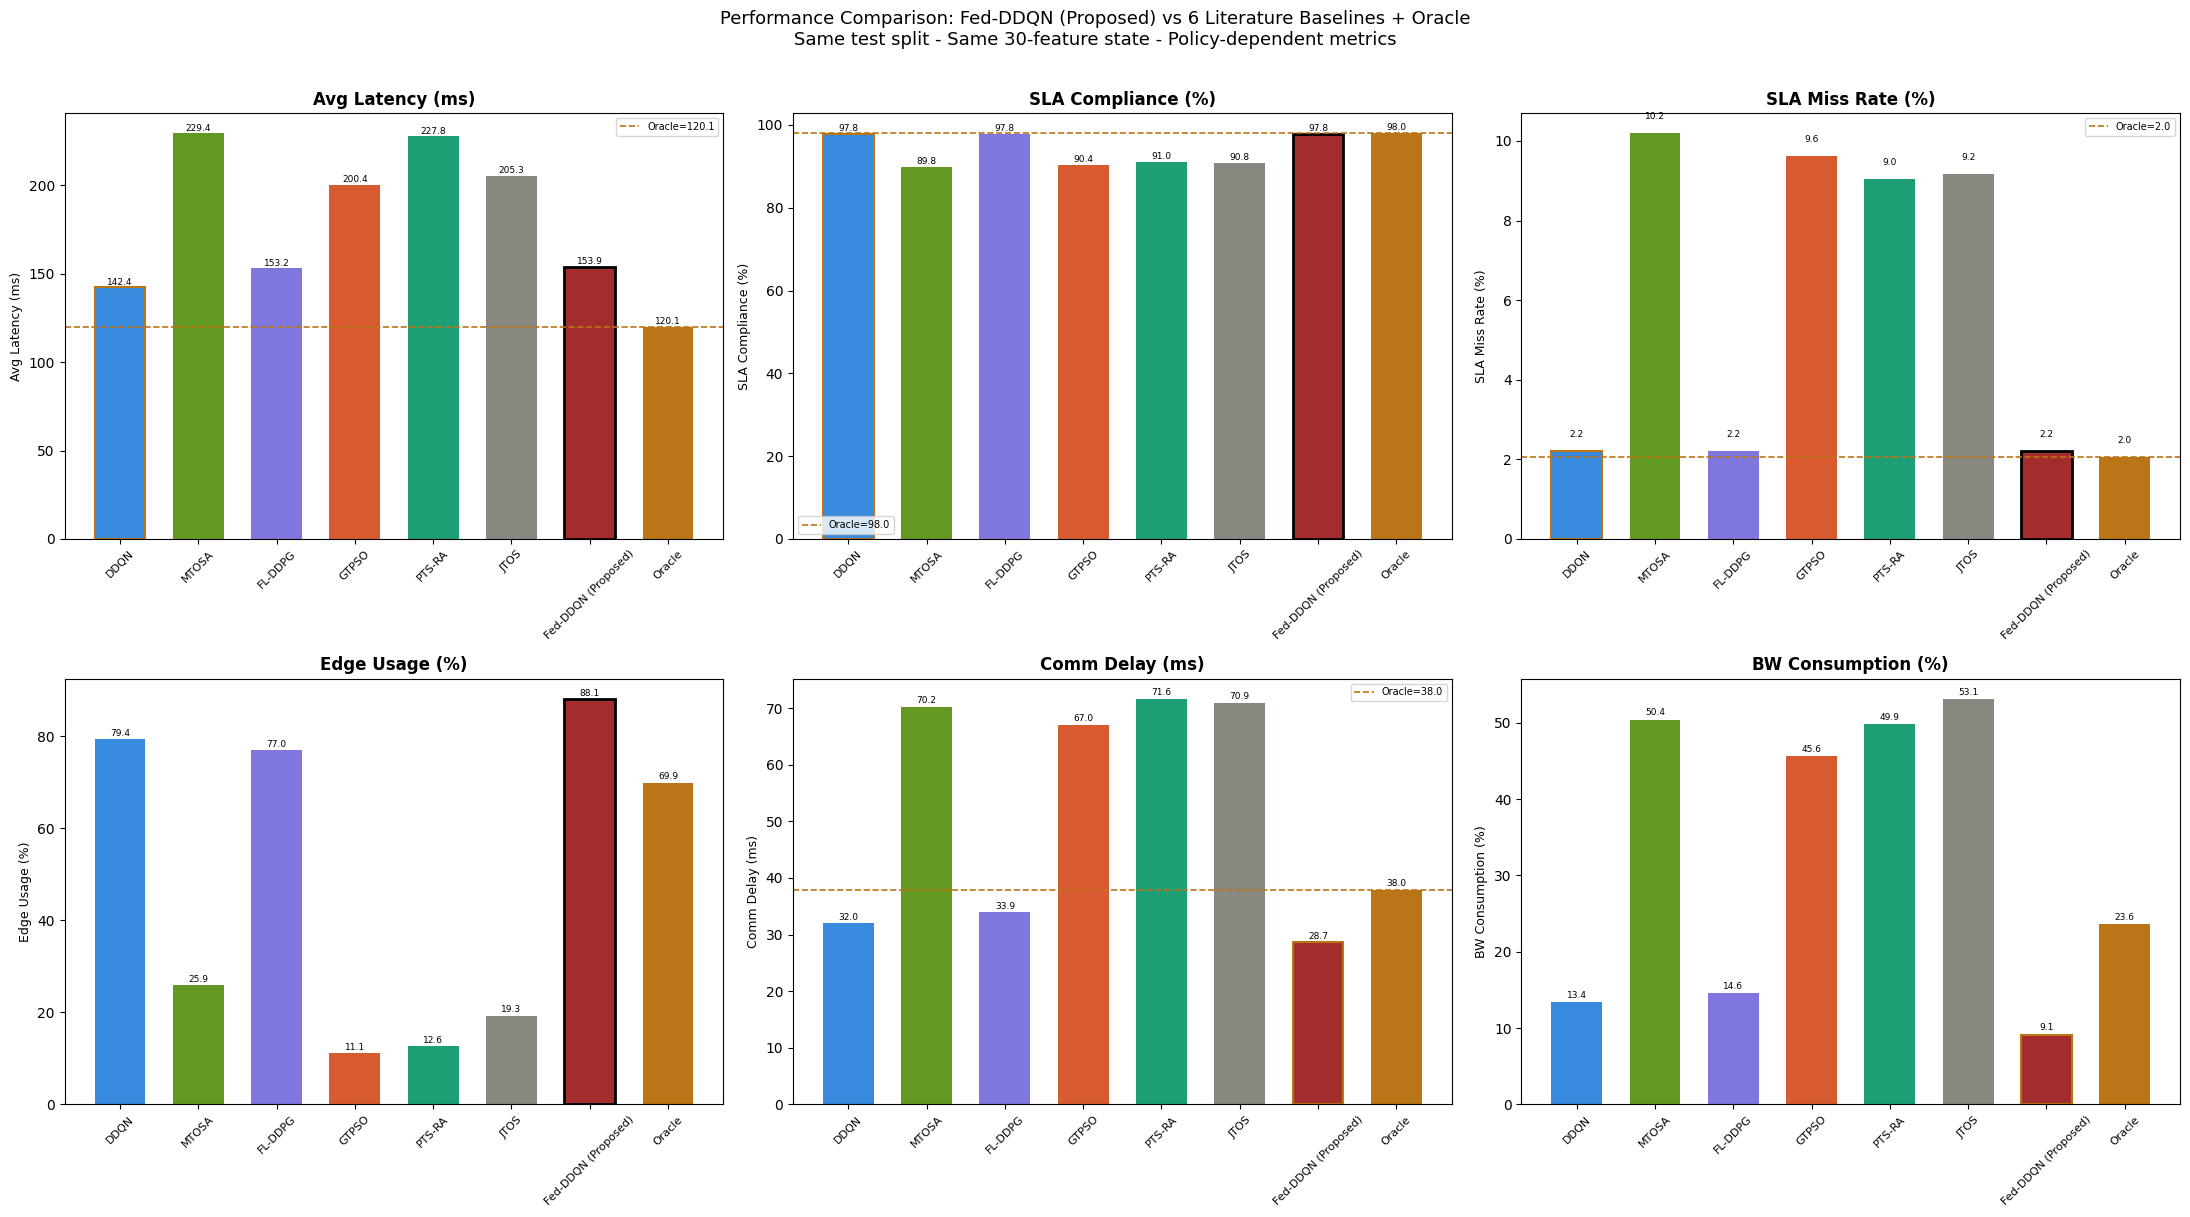

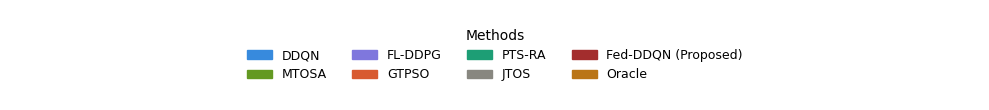

[CHART] 6-metric comparison across 8 methods complete.


In [19]:
methods=df_compare.index.tolist()
METHOD_COLORS={
    'DDQN':'#378ADD','MTOSA':'#639922','FL-DDPG':'#7F77DD',
    'GTPSO':'#D85A30','PTS-RA':'#1D9E75','JTOS':'#888780',
    'Fed-DDQN (Proposed)':'#A32D2D','Oracle':'#BA7517',
}
colors=[METHOD_COLORS.get(m,'#888780') for m in methods]
metrics     =['Avg Latency','SLA %','SLA Miss %','Edge Usage %','Comm Delay (ms)','BW Consump %']
titles      =['Avg Latency (ms)','SLA Compliance (%)','SLA Miss Rate (%)','Edge Usage (%)','Comm Delay (ms)','BW Consumption (%)']
lower_better=[True,False,True,None,True,True]

fig,axes=plt.subplots(2,3,figsize=(22,12))
axes_flat=axes.flatten()
for ax,metric,title,lb in zip(axes_flat,metrics,titles,lower_better):
    vals=df_compare[metric].values
    bars=ax.bar(methods,vals,color=colors,edgecolor='none',width=0.65)
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.tick_params(axis='x',rotation=45,labelsize=8)
    ax.set_ylabel(title,fontsize=9)
    if 'Fed-DDQN (Proposed)' in methods:
        pi=methods.index('Fed-DDQN (Proposed)')
        bars[pi].set_edgecolor('black'); bars[pi].set_linewidth(2)
    non_oracle=[(i,v) for i,(m,v) in enumerate(zip(methods,vals)) if m!='Oracle']
    if non_oracle and lb is not None:
        bi=min(non_oracle,key=lambda x:x[1])[0] if lb else max(non_oracle,key=lambda x:x[1])[0]
        bars[bi].set_edgecolor('#BA7517'); bars[bi].set_linewidth(1.5)
    if 'Oracle' in df_compare.index and metric in ['Avg Latency','SLA %','SLA Miss %','Comm Delay (ms)']:
        ov=df_compare.loc['Oracle',metric]
        ax.axhline(ov,color='#BA7517',linestyle='--',linewidth=1.2,label=f'Oracle={ov:.1f}')
        ax.legend(fontsize=7)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f'{v:.1f}',
                ha='center',va='bottom',fontsize=6.5)
plt.suptitle(
    'Performance Comparison: Fed-DDQN (Proposed) vs 6 Literature Baselines + Oracle\n'
    'Same test split - Same 30-feature state - Policy-dependent metrics',
    fontsize=13,y=1.01)
plt.tight_layout(); plt.show()
from matplotlib.patches import Patch
legend_handles=[Patch(color=METHOD_COLORS.get(m,'#888780'),label=m) for m in methods]
fig2,ax2=plt.subplots(figsize=(10,1.2)); ax2.axis('off')
ax2.legend(handles=legend_handles,loc='center',ncol=4,fontsize=9,frameon=False,title='Methods',title_fontsize=10)
plt.tight_layout(); plt.show()
print(f'[CHART] 6-metric comparison across {len(methods)} methods complete.')


## Cell 18b - Extended Analytics: Latency/SLA/Rejection vs Number of Tasks + Convergence

Line plots matching exampledraft1 Figs 4-9 and exampledraft2 Figs 3-6:
performance curves vs number of tasks (50-300), convergence curves, task-type SLA breakdown.


Computing per-node curves with cached actions/results ...
  n=50 done
  n=100 done
  n=150 done
  n=200 done
  n=250 done
  n=300 done


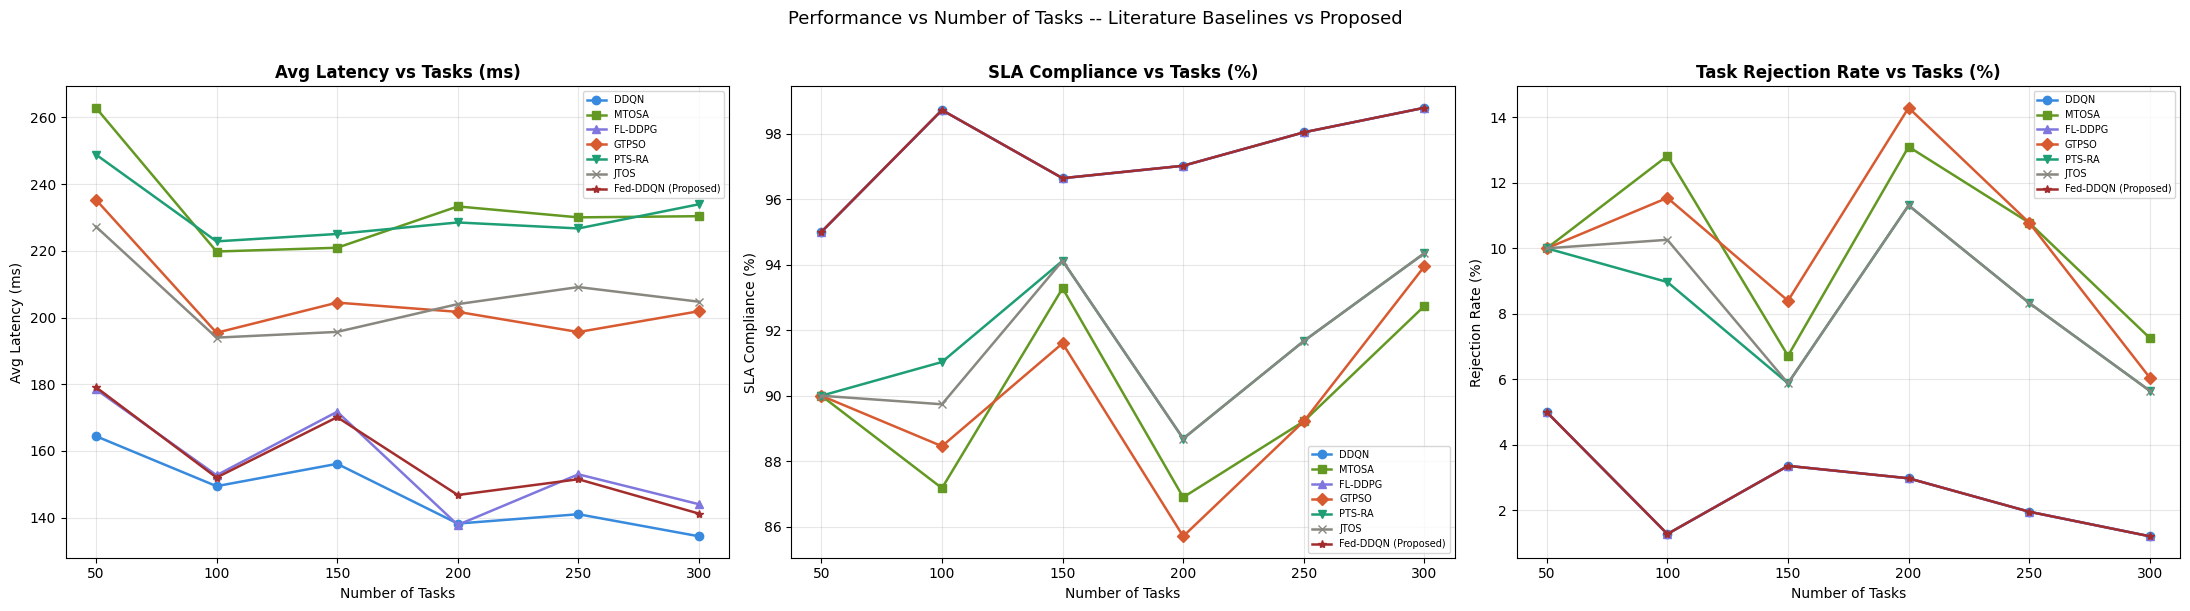

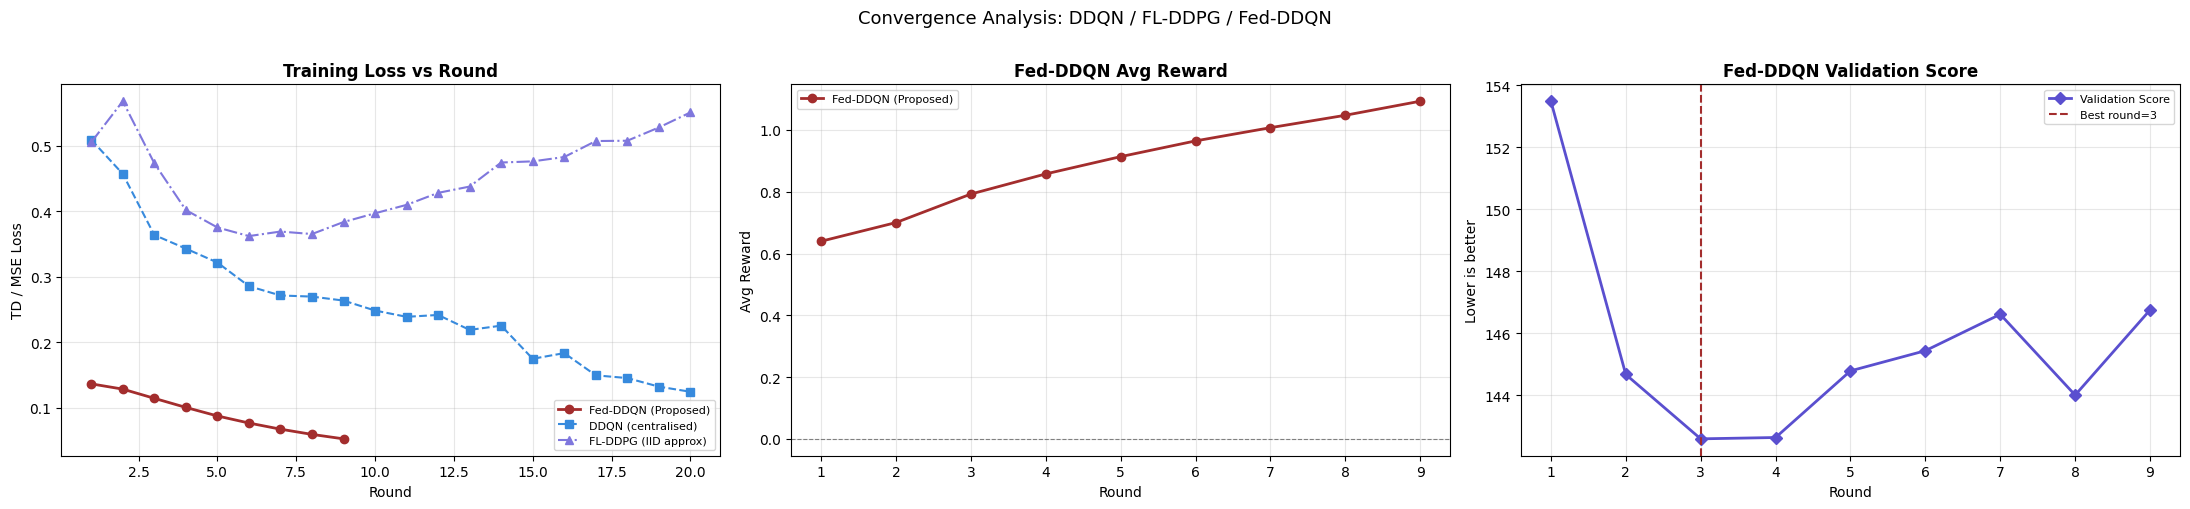


=== SLA Compliance by Task Type ===
                   DDQN   MTOSA  FL-DDPG   GTPSO  PTS-RA    JTOS  Fed-DDQN (Proposed)
Task Type                                                                            
ai               100.00  100.00   100.00  100.00  100.00  100.00               100.00
emergency         73.48   21.97    73.48    6.82   40.91   40.15                73.48
firmware_update  100.00  100.00   100.00  100.00  100.00  100.00               100.00
image            100.00  100.00   100.00  100.00  100.00  100.00               100.00
sensor            99.72   98.43    99.72   99.29   98.43   98.43                99.72
telemetry        100.00  100.00   100.00  100.00  100.00  100.00               100.00
video            100.00  100.00   100.00  100.00  100.00  100.00               100.00
voice             92.98   44.21    92.98   55.79   45.45   44.63                92.98


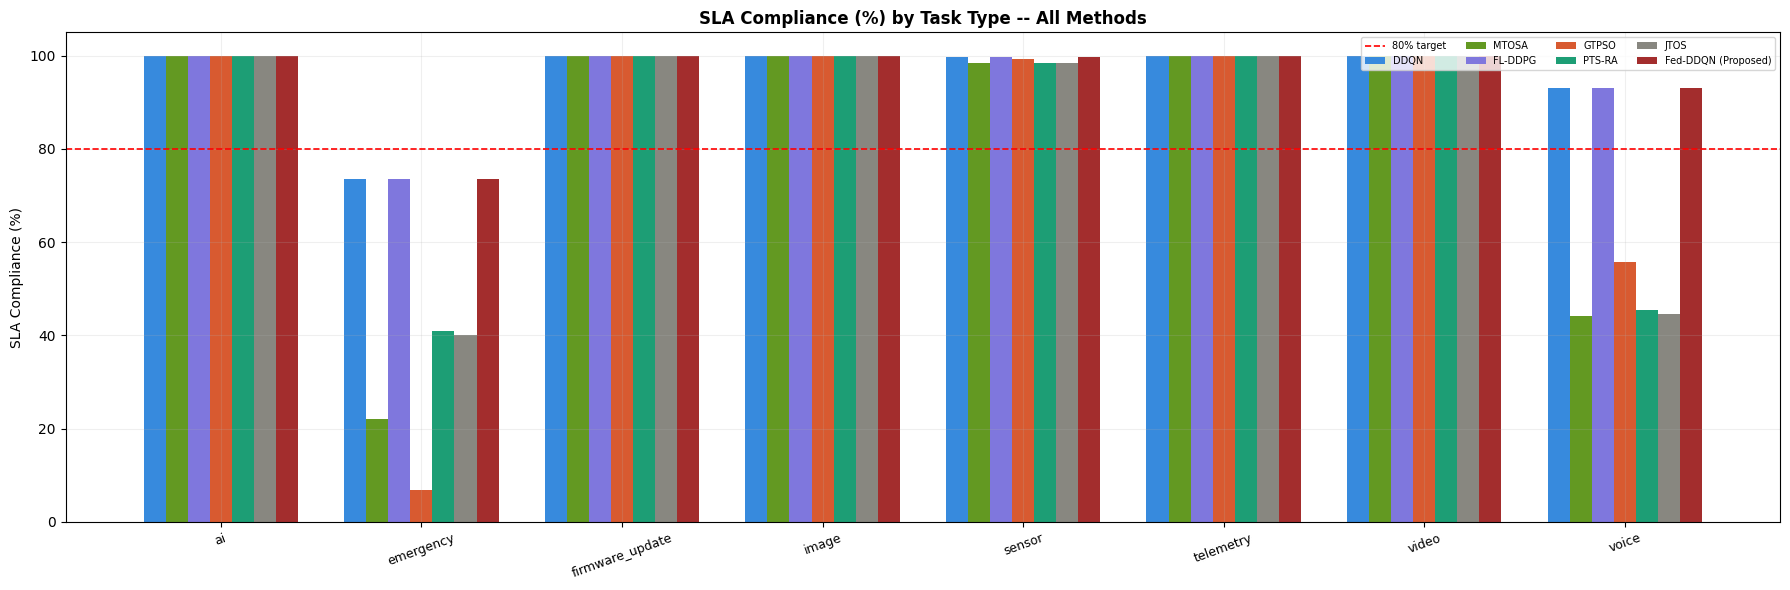

Extended analytics complete.


In [20]:
NODE_COUNTS = [50, 100, 150, 200, 250, 300]
PLOT_POLICIES = [
    ("DDQN", "#378ADD", "-o"),
    ("MTOSA", "#639922", "-s"),
    ("FL-DDPG", "#7F77DD", "-^"),
    ("GTPSO", "#D85A30", "-D"),
    ("PTS-RA", "#1D9E75", "-v"),
    ("JTOS", "#888780", "-x"),
    ("Fed-DDQN (Proposed)", "#A32D2D", "-*"),
]

def evaluate_subset(method, idx):
    sub_df = eval_sample.iloc[idx].reset_index(drop=True)
    sub_raw = eval_raw[idx]
    cached_actions = actions_by_method[method][idx]
    return evaluate_actions(method, cached_actions, sub_df, sub_raw)

if RUN_FULL_ANALYTICS:
    print("Computing per-node curves with cached actions/results ...")
    curves_lat = {name: [] for name, _, _ in PLOT_POLICIES}
    curves_sla = {name: [] for name, _, _ in PLOT_POLICIES}
    curves_rej = {name: [] for name, _, _ in PLOT_POLICIES}
    rng_curve = np.random.default_rng(42)
    for n in NODE_COUNTS:
        idx = rng_curve.choice(len(eval_sample), size=min(n, len(eval_sample)), replace=False)
        for method, _, _ in PLOT_POLICIES:
            res = evaluate_subset(method, idx)
            curves_lat[method].append(res["Avg Latency"])
            curves_sla[method].append(res["SLA %"])
            curves_rej[method].append(res["SLA Miss %"])
        print(f"  n={n} done")

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    for method, color, marker in PLOT_POLICIES:
        axes[0].plot(NODE_COUNTS, curves_lat[method], marker, color=color, label=method, linewidth=1.8, markersize=6)
        axes[1].plot(NODE_COUNTS, curves_sla[method], marker, color=color, label=method, linewidth=1.8, markersize=6)
        axes[2].plot(NODE_COUNTS, curves_rej[method], marker, color=color, label=method, linewidth=1.8, markersize=6)
    for ax, title, ylabel in zip(
        axes,
        ["Avg Latency vs Tasks (ms)", "SLA Compliance vs Tasks (%)", "Task Rejection Rate vs Tasks (%)"],
        ["Avg Latency (ms)", "SLA Compliance (%)", "Rejection Rate (%)"],
    ):
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Number of Tasks")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
    plt.suptitle("Performance vs Number of Tasks -- Literature Baselines vs Proposed", fontsize=13, y=1.01)
    plt.tight_layout()
    if RUN_PLOTS: plt.show()
    else: plt.close()

    fig2, axes2 = plt.subplots(1, 3, figsize=(22, 5))
    axes2[0].plot(range(1, len(federated_losses) + 1), federated_losses, "-o", color="#A32D2D", label="Fed-DDQN (Proposed)", linewidth=2)
    axes2[0].plot(range(1, len(cent_losses) + 1), cent_losses, "-s", color="#378ADD", label="DDQN (centralised)", linewidth=1.5, linestyle="--")
    axes2[0].plot(range(1, len(feddpg_losses) + 1), feddpg_losses, "-^", color="#7F77DD", label="FL-DDPG (IID approx)", linewidth=1.5, linestyle="-.")
    axes2[0].set_title("Training Loss vs Round", fontweight="bold")
    axes2[0].set_xlabel("Round"); axes2[0].set_ylabel("TD / MSE Loss")
    axes2[0].legend(fontsize=8); axes2[0].grid(alpha=0.3)
    axes2[1].plot(range(1, len(federated_rewards) + 1), federated_rewards, "-o", color="#A32D2D", label="Fed-DDQN (Proposed)", linewidth=2)
    axes2[1].axhline(0, color="gray", linestyle="--", lw=0.8)
    axes2[1].set_title("Fed-DDQN Avg Reward", fontweight="bold")
    axes2[1].set_xlabel("Round"); axes2[1].set_ylabel("Avg Reward")
    axes2[1].legend(fontsize=8); axes2[1].grid(alpha=0.3)
    axes2[2].plot(range(1, len(validation_scores) + 1), validation_scores, "-D", color="#5A4FCF", label="Validation Score", linewidth=2)
    if best_round:
        axes2[2].axvline(best_round, color="#A32D2D", linestyle="--", label=f"Best round={best_round}")
    axes2[2].set_title("Fed-DDQN Validation Score", fontweight="bold")
    axes2[2].set_xlabel("Round"); axes2[2].set_ylabel("Lower is better")
    axes2[2].legend(fontsize=8); axes2[2].grid(alpha=0.3)
    plt.suptitle("Convergence Analysis: DDQN / FL-DDPG / Fed-DDQN", fontsize=13, y=1.01)
    plt.tight_layout()
    if RUN_PLOTS: plt.show()
    else: plt.close()

    print("\n=== SLA Compliance by Task Type ===")
    tt_rows = []
    for task_type in sorted(eval_sample["task_type"].unique()):
        idx = np.flatnonzero(eval_sample["task_type"].to_numpy() == task_type)
        row_tt = {"Task Type": task_type}
        for method, _, _ in PLOT_POLICIES:
            row_tt[method] = evaluate_subset(method, idx)["SLA %"] if len(idx) else 0.0
        tt_rows.append(row_tt)
    df_tt = pd.DataFrame(tt_rows).set_index("Task Type")
    print(df_tt.to_string())
    fig3, ax3 = plt.subplots(figsize=(18, 6))
    x_tt = np.arange(len(df_tt.index)); w = 0.11
    for i, (method, color, _) in enumerate(PLOT_POLICIES):
        ax3.bar(x_tt + i * w - w * 3, df_tt[method].values, w, label=method, color=color)
    ax3.set_xticks(x_tt); ax3.set_xticklabels(df_tt.index, rotation=20, fontsize=9)
    ax3.axhline(80, color="red", linestyle="--", lw=1.2, label="80% target")
    ax3.set_title("SLA Compliance (%) by Task Type -- All Methods", fontweight="bold")
    ax3.set_ylabel("SLA Compliance (%)"); ax3.legend(fontsize=7, ncol=4); ax3.grid(alpha=0.2)
    plt.tight_layout()
    if RUN_PLOTS: plt.show()
    else: plt.close()
    print("Extended analytics complete.")
else:
    print("RUN_FULL_ANALYTICS=False; skipped extended analytics and repeated plots.")

## Cell 19 – DDQN Per-Task-Type Breakdown

=== Fed-DDQN Performance by Task Type ===

           Type    N Avg_DDQN Avg_Base Improv% Edge% Cloud%  SLA%
             ai  393    309.0    303.6    -1.8  52.2   47.8 100.0
      emergency  198     33.4    188.1    82.3 100.0    0.0  76.3
firmware_update  107    281.9    303.8     7.2  43.0   57.0 100.0
          image 1181    266.8    246.5    -8.2  91.3    8.7 100.0
         sensor 1098     35.8    176.5    79.7 100.0    0.0  99.9
      telemetry  390     49.8    177.2    71.9 100.0    0.0 100.0
          video  271    310.3    258.3   -20.1  49.8   50.2 100.0
          voice  435     65.1    187.1    65.2 100.0    0.0  90.3


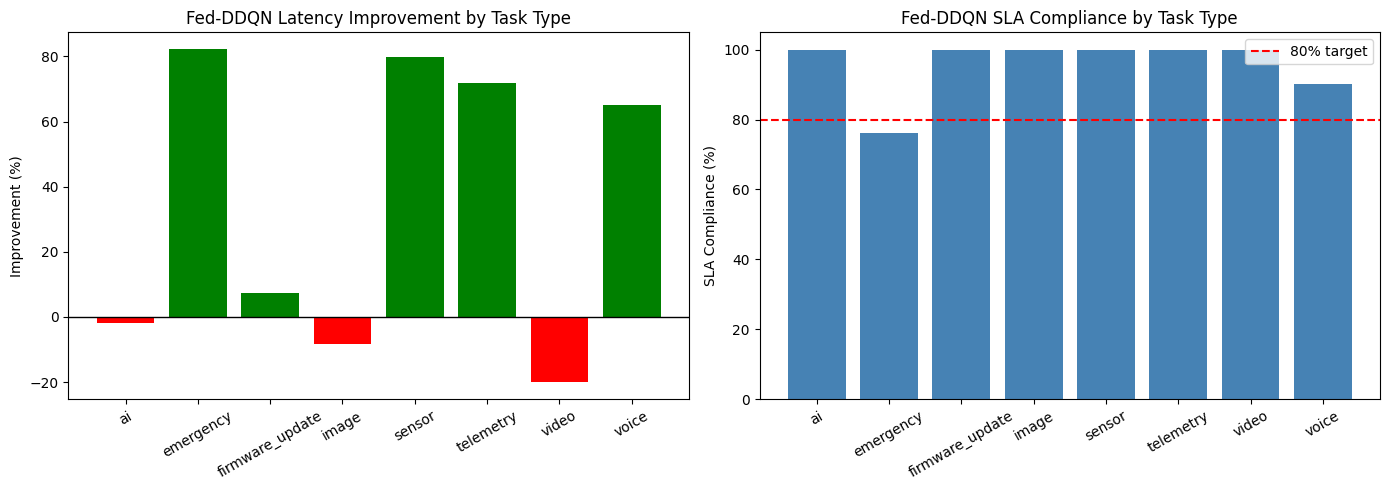

In [21]:
print("=== Fed-DDQN Performance by Task Type ===\n")
rows_out = []
fed_actions_sample = get_policy_actions("Fed-DDQN (Proposed)", sample_X, sample_raw, sample_tasks)

for task_type in sorted(sample_tasks["task_type"].unique()):
    idx = np.flatnonzero(sample_tasks["task_type"].to_numpy() == task_type)
    if len(idx) == 0:
        continue
    sub_df = sample_tasks.iloc[idx].reset_index(drop=True)
    sub_raw = sample_raw[idx]
    sub_actions = fed_actions_sample[idx]
    res = evaluate_actions("Fed-DDQN (Proposed)", sub_actions, sub_df, sub_raw)

    lat_e = sub_df["edge_latency"].to_numpy(dtype=np.float32)
    lat_c = sub_df["cloud_latency"].to_numpy(dtype=np.float32)
    valid = (lat_e < EDGE_LAT_CAP) | (lat_c < CLOUD_LAT_CAP)
    actions_v = sub_actions[valid]
    model_lats = np.where(actions_v == 0, lat_e[valid], lat_c[valid])
    cloud_lats = lat_c[valid]
    if len(model_lats) == 0:
        continue
    improvement = (cloud_lats.mean() - model_lats.mean()) / max(float(cloud_lats.mean()), 1e-6) * 100.0
    rows_out.append({
        "Type": task_type,
        "N": int(res["N Eval"]),
        "Avg_DDQN": f"{res['Avg Latency']:.1f}",
        "Avg_Base": f"{cloud_lats.mean():.1f}",
        "Improv%": f"{improvement:.1f}",
        "Edge%": f"{res['Edge Usage %']:.1f}",
        "Cloud%": f"{100.0 - res['Edge Usage %']:.1f}",
        "SLA%": f"{res['SLA %']:.1f}",
    })

print(pd.DataFrame(rows_out).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
types = [r["Type"] for r in rows_out]
imps = [float(r["Improv%"]) for r in rows_out]
cols = ["green" if value >= 0 else "red" for value in imps]
axes[0].bar(types, imps, color=cols)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Fed-DDQN Latency Improvement by Task Type")
axes[0].set_ylabel("Improvement (%)")
axes[0].tick_params(axis="x", rotation=30)
slas = [float(r["SLA%"]) for r in rows_out]
axes[1].bar(types, slas, color="steelblue")
axes[1].axhline(80, color="red", linestyle="--", label="80% target")
axes[1].set_title("Fed-DDQN SLA Compliance by Task Type")
axes[1].set_ylabel("SLA Compliance (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
plt.tight_layout(); plt.show()

## Cell 19b - Multi-Seed Testing, Ablation Study, and Scenario-Wise Test Tables

This cell evaluates the proposed Fed-DDQN more rigorously. It trains or loads
Fed-DDQN variants across multiple seeds, aggregates mean/std metrics, and reports
scenario-wise performance on the untouched test split.

MULTI-SEED + ABLATION SUITE FOR PROPOSED FED-DDQN
Seeds: [42, 77, 123]
Quick mode: True | Final paper seeds: [42, 77, 123, 2025, 999]
MAX_STEPS remains 8000
Full Fed-DDQN              seed=42    lat=155.805 SLA=97.72% rej=3.69% cache=False
Full Fed-DDQN              seed=77    lat=147.070 SLA=97.72% rej=3.69% cache=False
Full Fed-DDQN              seed=123   lat=149.187 SLA=97.72% rej=3.69% cache=False
No Prioritized Replay      seed=42    lat=142.096 SLA=97.72% rej=3.69% cache=False
No Prioritized Replay      seed=77    lat=142.190 SLA=97.72% rej=3.69% cache=False
No Prioritized Replay      seed=123   lat=141.807 SLA=97.73% rej=3.68% cache=False
No FedProx                 seed=42    lat=150.404 SLA=97.73% rej=3.68% cache=False
No FedProx                 seed=77    lat=145.386 SLA=97.74% rej=3.67% cache=False
No FedProx                 seed=123   lat=144.390 SLA=97.74% rej=3.67% cache=False
Hard Target Update         seed=42    lat=151.804 SLA=97.72% rej=3.69% cache=False
Hard Target U

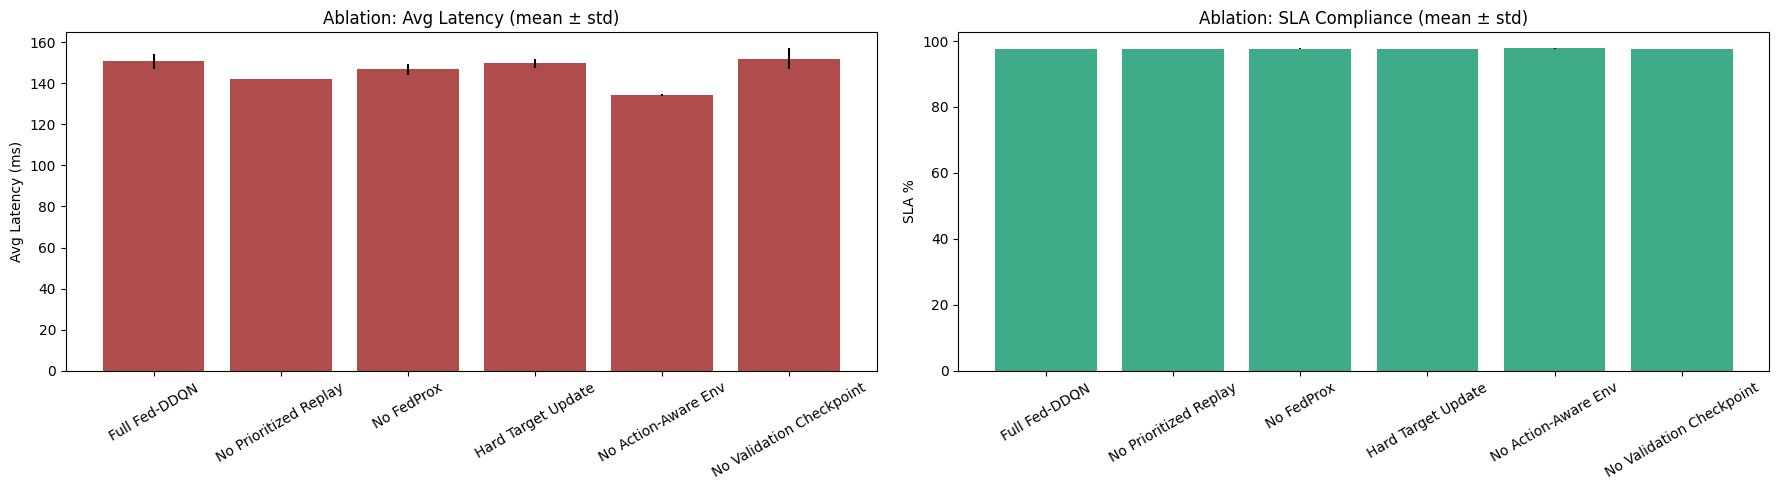

In [22]:
def set_experiment_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def safe_name(name):
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in name).strip("_")


def clone_q_network(source_model):
    model_copy = QNetwork(X_train.shape[1]).to(device)
    model_copy.load_state_dict(source_model.state_dict())
    return model_copy


class AblationOffloadEnv(OffloadEnv):
    """OffloadEnv variant that can disable action-aware state dynamics for ablation."""
    def __init__(self, task_df, feature_matrix, action_aware=True):
        super().__init__(task_df, feature_matrix)
        self.action_aware = bool(action_aware)

    def _state(self, idx: int) -> torch.Tensor:
        if self.action_aware:
            return super()._state(idx)
        obs = self.X[idx].copy()
        return torch.from_numpy(np.clip(obs, -10.0, 10.0).astype(np.float32, copy=False))

    def _dynamic_latencies(self, idx: int):
        if self.action_aware:
            return super()._dynamic_latencies(idx)
        return float(self.edge_lat[idx]), float(self.cloud_lat[idx])

    def _apply_action_pressure(self, idx: int, action: int):
        if self.action_aware:
            super()._apply_action_pressure(idx, action)
        else:
            self.edge_pressure = 0.0
            self.cloud_pressure = 0.0
            self.network_pressure = 0.0
            self.energy_debt = 0.0


ABLATION_CONFIGS = [
    {"name": "Full Fed-DDQN", "use_prioritized": True, "mu_proximal": MU_PROXIMAL, "soft_tau": TARGET_TAU, "action_aware_env": True, "validation_checkpoint": True},
    {"name": "No Prioritized Replay", "use_prioritized": False, "mu_proximal": MU_PROXIMAL, "soft_tau": TARGET_TAU, "action_aware_env": True, "validation_checkpoint": True},
    {"name": "No FedProx", "use_prioritized": True, "mu_proximal": 0.0, "soft_tau": TARGET_TAU, "action_aware_env": True, "validation_checkpoint": True},
    {"name": "Hard Target Update", "use_prioritized": True, "mu_proximal": MU_PROXIMAL, "soft_tau": None, "action_aware_env": True, "validation_checkpoint": True},
    {"name": "No Action-Aware Env", "use_prioritized": True, "mu_proximal": MU_PROXIMAL, "soft_tau": TARGET_TAU, "action_aware_env": False, "validation_checkpoint": True},
    {"name": "No Validation Checkpoint", "use_prioritized": True, "mu_proximal": MU_PROXIMAL, "soft_tau": TARGET_TAU, "action_aware_env": True, "validation_checkpoint": False},
]


def make_variant_cache_path(config, seed):
    variant_key = safe_name(config["name"])
    return os.path.join(multiseed_cache_dir, f"{cache_prefix}_{variant_key}_seed{int(seed)}.pt")


def build_variant_zone_envs(action_aware_env=True):
    envs = {}
    for zone in zone_names:
        zmask = train_df["zone"] == zone
        z_idx = zmask.values.nonzero()[0]
        if len(z_idx) == 0:
            continue
        z_df = train_df.iloc[z_idx].reset_index(drop=True)
        z_X = X_train_sc[z_idx]
        envs[zone] = AblationOffloadEnv(z_df, z_X, action_aware=action_aware_env)
    return envs


def evaluate_model_metrics(q_model, X_np, eval_df, raw_np=None, mask=None):
    q_model.eval()
    if mask is None:
        idx = np.arange(len(eval_df))
    else:
        idx = np.flatnonzero(np.asarray(mask, dtype=bool))
    if len(idx) == 0:
        return {"N Eval": 0, "Avg Latency": 0.0, "SLA %": 0.0, "SLA Miss %": 0.0, "Rejection %": 0.0, "Edge Usage %": 0.0, "Comm Delay (ms)": 0.0, "BW Consump %": 0.0}, np.array([], dtype=np.int64)

    X_sub = X_np[idx]
    df_sub = eval_df.iloc[idx].reset_index(drop=True)
    raw_sub = raw_np[idx] if raw_np is not None else features_raw[test_mask][idx]
    with torch.inference_mode():
        if X_np is X_test_sc and len(idx) == len(test_df) and np.array_equal(idx, np.arange(len(test_df))):
            xb = X_test_dev
        elif X_np is X_val_sc and len(idx) == len(val_df) and np.array_equal(idx, np.arange(len(val_df))):
            xb = X_val_dev
        else:
            xb = torch.tensor(X_sub, dtype=torch.float32, device=device)
        actions = torch.argmax(q_model(xb), dim=1).cpu().numpy().astype(np.int64)
    metrics = evaluate_actions("Fed-DDQN Variant", actions, df_sub, raw_sub)
    lat_e = df_sub["edge_latency"].to_numpy(dtype=np.float32)
    lat_c = df_sub["cloud_latency"].to_numpy(dtype=np.float32)
    valid = (lat_e < EDGE_LAT_CAP) | (lat_c < CLOUD_LAT_CAP)
    if valid.any():
        actions_v = actions[valid]
        lat = np.where(actions_v == 0, lat_e[valid], lat_c[valid])
        sla = df_sub.loc[valid, "task_type"].map(SLA_MS).fillna(9999).to_numpy(dtype=np.float32)
        impossible = df_sub.loc[valid].get("impossible_deadline", pd.Series(0, index=df_sub.loc[valid].index)).to_numpy(dtype=np.float32)
        metrics["Rejection %"] = round(float(((lat >= sla) | (impossible > 0.5)).mean() * 100.0), 2)
    else:
        metrics["Rejection %"] = 0.0
    return metrics, actions


def train_or_load_fed_variant(config, seed):
    variant_path = make_variant_cache_path(config, seed)
    model = QNetwork(X_train.shape[1]).to(device)

    if (not FORCE_RETRAIN_MULTI_SEED_ABLATION) and os.path.exists(variant_path):
        payload = torch.load(variant_path, map_location=device)
        model.load_state_dict(payload["state_dict"])
        payload["loaded_from_cache"] = True
        return model, payload

    if config["name"] == "Full Fed-DDQN" and int(seed) == 42 and not FORCE_RETRAIN_MULTI_SEED_ABLATION and "global_q" in globals():
        model.load_state_dict(global_q.state_dict())
        payload = {
            "state_dict": _state_dict_cpu(model),
            "seed": int(seed),
            "ablation": config["name"],
            "losses": list(federated_losses),
            "rewards": list(federated_rewards),
            "validation_scores": list(validation_scores),
            "best_val_score": float(best_val_score),
            "best_round": int(best_round),
            "rounds_ran": int(rounds_ran),
            "loaded_from_cache": False,
            "reused_current_global_q": True,
        }
        torch.save(payload, variant_path)
        return model, payload

    if LOAD_EXPERIMENT_RESULTS_ONLY:
        raise FileNotFoundError(f"Missing cached variant while LOAD_EXPERIMENT_RESULTS_ONLY=True: {variant_path}")

    set_experiment_seed(seed)
    model = QNetwork(X_train.shape[1]).to(device)
    target_model = clone_q_network(model)
    local_envs = build_variant_zone_envs(config["action_aware_env"])
    local_models = {zone: clone_q_network(model) for zone in local_envs}
    local_targets = {zone: clone_q_network(model) for zone in local_envs}
    local_opts = {zone: optim.AdamW(local_models[zone].parameters(), lr=5e-4, weight_decay=1e-4) for zone in local_envs}
    local_buffers = {zone: ReplayBuffer(30000) for zone in local_envs}
    local_eps = {zone: EPSILON_START for zone in local_envs}
    losses, rewards, val_scores = [], [], []
    best_state = _state_dict_cpu(model)
    best_target_state = _state_dict_cpu(target_model)
    best_score = float("inf")
    best_rnd = 0
    bad_rounds = 0
    huber = nn.SmoothL1Loss(reduction="none")

    for rnd in range(ROUNDS):
        beta = min(1.0, PRIORITY_BETA_START + (1.0 - PRIORITY_BETA_START) * rnd / PRIORITY_BETA_FRAMES)
        round_models, round_weights = [], []
        round_loss = 0.0
        round_reward = 0.0
        round_batches = 0
        round_steps = 0

        for zone, env in local_envs.items():
            lm = local_models[zone]
            tgt = local_targets[zone]
            opt = local_opts[zone]
            buf = local_buffers[zone]
            lm.load_state_dict(model.state_dict())
            tgt.load_state_dict(target_model.state_dict())
            lm.train()
            state = env.reset().to(device)
            zone_reward = 0.0

            for step in range(MAX_STEPS):
                eps = local_eps[zone]
                if np.random.rand() < eps:
                    action = int(np.random.randint(0, 2))
                else:
                    with torch.no_grad():
                        action = int(torch.argmax(lm(state.unsqueeze(0))).item())
                next_state, reward, done, _ = env.step(action)
                buf.push(state.detach().cpu(), action, reward, next_state.detach().cpu())
                round_reward += reward
                zone_reward += reward
                round_steps += 1

                if len(buf) > BATCH_SIZE:
                    if config["use_prioritized"]:
                        sb, ab, rb, nsb, idxs, isw = buf.sample_prioritized(BATCH_SIZE, beta=beta)
                        isw = isw.to(device)
                    else:
                        sb, ab, rb, nsb = buf.sample(BATCH_SIZE)
                        idxs = None
                        isw = torch.ones(BATCH_SIZE, dtype=torch.float32, device=device)
                    sb = sb.to(device); nsb = nsb.to(device)
                    ab = ab.to(device); rb = rb.to(device)
                    current_q = lm(sb).gather(1, ab.unsqueeze(1)).squeeze(1)
                    with torch.no_grad():
                        next_actions = torch.argmax(lm(nsb), dim=1)
                        next_q = tgt(nsb).gather(1, next_actions.unsqueeze(1)).squeeze(1)
                        target_q_values = rb + GAMMA * next_q
                    td_errors = current_q - target_q_values
                    td_loss = (isw * huber(current_q, target_q_values)).mean()
                    drift = sum(torch.sum((p - pg.detach()) ** 2) for p, pg in zip(lm.parameters(), model.parameters()))
                    loss = td_loss + (float(config["mu_proximal"]) / 2.0) * drift
                    opt.zero_grad(set_to_none=True)
                    loss.backward()
                    nn.utils.clip_grad_norm_(lm.parameters(), 1.0)
                    opt.step()
                    if config["soft_tau"] is None:
                        if step % TARGET_UPDATE == 0:
                            tgt.load_state_dict(lm.state_dict())
                    else:
                        soft_update(tgt, lm, tau=float(config["soft_tau"]))
                    if config["use_prioritized"] and idxs is not None:
                        buf.update_priorities(idxs, td_errors.detach().abs().cpu())
                    round_loss += float(td_loss.item())
                    round_batches += 1

                state = next_state.to(device)
                if done:
                    state = env.reset().to(device)

            local_eps[zone] = max(local_eps[zone] * EPSILON_DECAY, EPSILON_MIN)
            zone_avg_reward = zone_reward / max(MAX_STEPS, 1)
            perf_factor = float(np.clip(1.0 + 0.10 * zone_avg_reward, 0.60, 1.40))
            round_weights.append(len(env.df) * perf_factor)
            exported = QNetwork(X_train.shape[1])
            exported.load_state_dict({k: v.detach().cpu() for k, v in lm.state_dict().items()})
            round_models.append(exported)

        averaged = federated_average(round_models, weights=round_weights).to(device)
        model.load_state_dict(averaged.state_dict())
        soft_update(target_model, model, tau=0.25)
        avg_loss = round_loss / max(round_batches, 1)
        avg_reward = round_reward / max(round_steps, 1)
        losses.append(avg_loss)
        rewards.append(avg_reward)
        val_metrics = evaluate_q_model_on_split(model, X_val_sc, val_df)
        score = fed_validation_score(val_metrics)
        val_scores.append(score)

        if score < best_score:
            best_score = score
            best_rnd = rnd + 1
            best_state = _state_dict_cpu(model)
            best_target_state = _state_dict_cpu(target_model)
            bad_rounds = 0
        else:
            bad_rounds += 1

        if config["validation_checkpoint"] and bad_rounds >= PATIENCE:
            break

    if config["validation_checkpoint"]:
        model.load_state_dict(best_state)
        target_model.load_state_dict(best_target_state)
    else:
        best_state = _state_dict_cpu(model)
        best_target_state = _state_dict_cpu(target_model)

    payload = {
        "state_dict": best_state,
        "target_state_dict": best_target_state,
        "seed": int(seed),
        "ablation": config["name"],
        "config": config,
        "losses": losses,
        "rewards": rewards,
        "validation_scores": val_scores,
        "best_val_score": float(best_score),
        "best_round": int(best_rnd),
        "rounds_ran": int(len(losses)),
        "loaded_from_cache": False,
        "reused_current_global_q": False,
    }
    torch.save(payload, variant_path)
    return model, payload


def mean_std_text(values, digits=3):
    arr = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
    if len(arr) == 0:
        return "0.000 ± 0.000"
    return f"{arr.mean():.{digits}f} ± {arr.std(ddof=0):.{digits}f}"


def build_scenario_masks(eval_df, raw_np):
    task_type = eval_df["task_type"].astype(str)
    scenario_masks = {
        "All test tasks": np.ones(len(eval_df), dtype=bool),
        "Normal traffic": (
            (raw_np[:, _F_N_CONG] < 0.5) &
            (raw_np[:, _F_N_OUTAGE] < 0.5) &
            (raw_np[:, _F_N_JITTER] < 0.5) &
            (raw_np[:, _F_E_QUEUE] < np.percentile(raw_np[:, _F_E_QUEUE], 75))
        ),
        "Congestion": raw_np[:, _F_N_CONG] >= 0.5,
        "Outage": raw_np[:, _F_N_OUTAGE] >= 0.5,
        "Jitter storm": raw_np[:, _F_N_JITTER] >= 0.5,
        "High edge queue": raw_np[:, _F_E_QUEUE] >= np.percentile(raw_np[:, _F_E_QUEUE], 90),
        "Emergency": task_type.eq("emergency").to_numpy(),
        "Real-time": eval_df.get("is_real_time", pd.Series(0, index=eval_df.index)).to_numpy(dtype=int) == 1,
        "Low battery": eval_df.get("is_low_battery", pd.Series(0, index=eval_df.index)).to_numpy(dtype=int) == 1,
        "AI/video-heavy": task_type.isin(["ai", "video"]).to_numpy(),
        "Firmware": task_type.eq("firmware_update").to_numpy(),
    }
    return {name: mask for name, mask in scenario_masks.items() if int(np.asarray(mask).sum()) > 0}


def load_cached_experiment_results():
    if not os.path.exists(results_cache_path):
        return None
    cached = pd.read_pickle(results_cache_path)
    expected_seeds = list(map(int, EXPERIMENT_SEEDS))
    if cached.get("cache_signature") != cache_signature:
        return None
    if cached.get("experiment_seeds") != expected_seeds:
        return None
    if cached.get("ablation_names") != [cfg["name"] for cfg in ABLATION_CONFIGS]:
        return None
    return cached


def save_experiment_results(payload):
    pd.to_pickle(payload, results_cache_path)
    print(f"Saved multi-seed/ablation result-table cache: {results_cache_path}")


def load_or_build_scenario_masks(test_raw_for_suite):
    if os.path.exists(scenario_mask_cache_path):
        try:
            mask_cache = np.load(scenario_mask_cache_path, allow_pickle=True)
            names = [str(x) for x in mask_cache["names"].tolist()]
            masks = {name: mask_cache[f"mask_{i}"].astype(bool) for i, name in enumerate(names)}
            if all(len(mask) == len(test_df) for mask in masks.values()):
                return masks, True
        except Exception as exc:
            print(f"Scenario mask cache ignored and rebuilt: {exc}")
    masks = build_scenario_masks(test_df, test_raw_for_suite)
    save_payload = {"names": np.array(list(masks.keys()), dtype=object)}
    for i, (name, mask) in enumerate(masks.items()):
        save_payload[f"mask_{i}"] = np.asarray(mask, dtype=bool)
    np.savez_compressed(scenario_mask_cache_path, **save_payload)
    return masks, False


def load_or_build_baseline_actions(test_raw_for_suite):
    if os.path.exists(actions_cache_path):
        try:
            cached = pd.read_pickle(actions_cache_path)
            if cached.get("cache_signature") == cache_signature and cached.get("n_test") == len(test_df):
                return cached["baseline_actions"], True
        except Exception as exc:
            print(f"Baseline action cache ignored and rebuilt: {exc}")
    baseline_methods = ["DDQN", "MTOSA", "FL-DDPG", "GTPSO", "PTS-RA", "JTOS", "Oracle"]
    baseline_actions = {method: get_policy_actions(method, X_test_sc, test_raw_for_suite, test_df) for method in baseline_methods}
    pd.to_pickle({"cache_signature": cache_signature, "n_test": len(test_df), "baseline_actions": baseline_actions}, actions_cache_path)
    return baseline_actions, False


multiseed_records = []
full_seed_actions = {}
variant_payloads = {}
results_loaded_from_cache = False

if RUN_MULTI_SEED_ABLATION:
    cached_results = None if FORCE_RETRAIN_MULTI_SEED_ABLATION else load_cached_experiment_results()
    if cached_results is not None:
        df_multiseed_raw = cached_results["df_multiseed_raw"]
        df_ablation_summary = cached_results["df_ablation_summary"]
        df_full_multiseed = cached_results["df_full_multiseed"]
        df_scenario_final = cached_results["df_scenario_final"]
        multiseed_records = cached_results.get("multiseed_records", df_multiseed_raw.to_dict("records"))
        results_loaded_from_cache = True
        print(f"Loaded cached multi-seed/ablation result tables: {results_cache_path}")
    else:
        if LOAD_EXPERIMENT_RESULTS_ONLY:
            raise FileNotFoundError(f"LOAD_EXPERIMENT_RESULTS_ONLY=True but result cache is missing or stale: {results_cache_path}")

        print("=" * 88)
        print("MULTI-SEED + ABLATION SUITE FOR PROPOSED FED-DDQN")
        print("=" * 88)
        print(f"Seeds: {EXPERIMENT_SEEDS}")
        print(f"Quick mode: {MULTI_SEED_QUICK_MODE} | Final paper seeds: {FINAL_PAPER_SEEDS}")
        print(f"MAX_STEPS remains {MAX_STEPS}")
        test_raw_for_suite = features_raw[test_mask].astype(np.float32, copy=False)

        for config in ABLATION_CONFIGS:
            for seed in EXPERIMENT_SEEDS:
                t0_suite = time.time()
                model_variant, payload = train_or_load_fed_variant(config, seed)
                metrics, actions = evaluate_model_metrics(model_variant, X_test_sc, test_df, test_raw_for_suite)
                if config["name"] == "Full Fed-DDQN":
                    full_seed_actions[int(seed)] = actions
                variant_payloads[(config["name"], int(seed))] = payload
                multiseed_records.append({
                    "Ablation": config["name"],
                    "Seed": int(seed),
                    "Avg Latency": metrics["Avg Latency"],
                    "SLA %": metrics["SLA %"],
                    "SLA Miss %": metrics["SLA Miss %"],
                    "Rejection %": metrics["Rejection %"],
                    "Edge Usage %": metrics["Edge Usage %"],
                    "Comm Delay (ms)": metrics["Comm Delay (ms)"],
                    "BW Consump %": metrics["BW Consump %"],
                    "Best Val Score": payload.get("best_val_score", np.nan),
                    "Best Round": payload.get("best_round", 0),
                    "Rounds Ran": payload.get("rounds_ran", 0),
                    "Loaded Cache": bool(payload.get("loaded_from_cache", False)),
                    "Runtime Sec": round(time.time() - t0_suite, 2),
                })
                print(f"{config['name']:<26s} seed={seed:<5d} "
                      f"lat={metrics['Avg Latency']:.3f} SLA={metrics['SLA %']:.2f}% "
                      f"rej={metrics['Rejection %']:.2f}% cache={payload.get('loaded_from_cache', False)}")

        df_multiseed_raw = pd.DataFrame(multiseed_records)
        ablation_rows = []
        for ablation_name, group in df_multiseed_raw.groupby("Ablation", sort=False):
            ablation_rows.append({
                "Ablation": ablation_name,
                "Runs": int(len(group)),
                "Avg Latency": mean_std_text(group["Avg Latency"], 3),
                "SLA %": mean_std_text(group["SLA %"], 2),
                "Rejection %": mean_std_text(group["Rejection %"], 2),
                "Edge Usage %": mean_std_text(group["Edge Usage %"], 2),
                "Best Val Score": mean_std_text(group["Best Val Score"], 3),
                "Rounds Ran": mean_std_text(group["Rounds Ran"], 1),
            })
        df_ablation_summary = pd.DataFrame(ablation_rows)
        df_full_multiseed = df_multiseed_raw[df_multiseed_raw["Ablation"] == "Full Fed-DDQN"].reset_index(drop=True)

        scenario_masks, scenario_masks_loaded_from_cache = load_or_build_scenario_masks(test_raw_for_suite)
        baseline_actions_full_test, baseline_actions_loaded_from_cache = load_or_build_baseline_actions(test_raw_for_suite)
        scenario_rows = []

        for scenario_name, mask in scenario_masks.items():
            mask = np.asarray(mask, dtype=bool)
            seed_metric_rows = []
            for seed, actions in full_seed_actions.items():
                seed_metric_rows.append(evaluate_actions("Full Fed-DDQN", actions[mask], test_df.loc[mask].reset_index(drop=True), test_raw_for_suite[mask]))
            scenario_rows.append({
                "Scenario": scenario_name,
                "Method": "Fed-DDQN Full (mean±std)",
                "N": int(mask.sum()),
                "Avg Latency": mean_std_text([row["Avg Latency"] for row in seed_metric_rows], 3),
                "SLA %": mean_std_text([row["SLA %"] for row in seed_metric_rows], 2),
                "SLA Miss %": mean_std_text([row["SLA Miss %"] for row in seed_metric_rows], 2),
                "Edge Usage %": mean_std_text([row["Edge Usage %"] for row in seed_metric_rows], 2),
                "Comm Delay (ms)": mean_std_text([row["Comm Delay (ms)"] for row in seed_metric_rows], 3),
                "BW Consump %": mean_std_text([row["BW Consump %"] for row in seed_metric_rows], 2),
            })
            for method, actions in baseline_actions_full_test.items():
                metrics = evaluate_actions(method, actions[mask], test_df.loc[mask].reset_index(drop=True), test_raw_for_suite[mask])
                scenario_rows.append({
                    "Scenario": scenario_name,
                    "Method": method,
                    "N": int(metrics["N Eval"]),
                    "Avg Latency": f"{metrics['Avg Latency']:.3f}",
                    "SLA %": f"{metrics['SLA %']:.2f}",
                    "SLA Miss %": f"{metrics['SLA Miss %']:.2f}",
                    "Edge Usage %": f"{metrics['Edge Usage %']:.2f}",
                    "Comm Delay (ms)": f"{metrics['Comm Delay (ms)']:.3f}",
                    "BW Consump %": f"{metrics['BW Consump %']:.2f}",
                })

        df_scenario_final = pd.DataFrame(scenario_rows)
        save_experiment_results({
            "cache_signature": cache_signature,
            "experiment_seeds": list(map(int, EXPERIMENT_SEEDS)),
            "ablation_names": [cfg["name"] for cfg in ABLATION_CONFIGS],
            "df_multiseed_raw": df_multiseed_raw,
            "df_ablation_summary": df_ablation_summary,
            "df_full_multiseed": df_full_multiseed,
            "df_scenario_final": df_scenario_final,
            "multiseed_records": multiseed_records,
        })

    print("\n=== Multi-Seed Raw Results ===")
    print(df_multiseed_raw.to_string(index=False))
    print("\n=== Ablation Summary (mean ± std across seeds) ===")
    print(df_ablation_summary.to_string(index=False))
    print("\n=== Scenario-Wise Final Test Table ===")
    print(df_scenario_final.to_string(index=False))

    if RUN_FULL_ANALYTICS:
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        lat_means = df_multiseed_raw.groupby("Ablation", sort=False)["Avg Latency"].mean()
        lat_stds = df_multiseed_raw.groupby("Ablation", sort=False)["Avg Latency"].std(ddof=0).fillna(0)
        axes[0].bar(lat_means.index, lat_means.values, yerr=lat_stds.values, color="#A32D2D", alpha=0.85)
        axes[0].set_title("Ablation: Avg Latency (mean ± std)")
        axes[0].set_ylabel("Avg Latency (ms)")
        axes[0].tick_params(axis="x", rotation=30)
        sla_means = df_multiseed_raw.groupby("Ablation", sort=False)["SLA %"].mean()
        sla_stds = df_multiseed_raw.groupby("Ablation", sort=False)["SLA %"].std(ddof=0).fillna(0)
        axes[1].bar(sla_means.index, sla_means.values, yerr=sla_stds.values, color="#1D9E75", alpha=0.85)
        axes[1].set_title("Ablation: SLA Compliance (mean ± std)")
        axes[1].set_ylabel("SLA %")
        axes[1].tick_params(axis="x", rotation=30)
        plt.tight_layout()
        if RUN_PLOTS:
            plt.show()
        else:
            plt.close()
else:
    df_multiseed_raw = pd.DataFrame()
    df_ablation_summary = pd.DataFrame()
    df_full_multiseed = pd.DataFrame()
    df_scenario_final = pd.DataFrame()
    results_loaded_from_cache = False
    print("RUN_MULTI_SEED_ABLATION=False; skipped v6.5 multi-seed ablation suite.")

## Cell 20 – Resource Allocation Targets

[FIX 5] Allocator now outputs **3 fractions**: CPU, Memory, and **Bandwidth**.
Bandwidth target = `task_size_mb / effective_uplink_bw` (clipped to [0.01, 1]).

In [23]:
def gen_alloc_target(task_row):
    '''Return (cpu_share, mem_share, bw_share) in [0.01, 1.0].'''
    t = int(task_row["arrival_time"])
    edge_id = int(task_row["assigned_edge_id"])
    edge = edge_idx.get((t, edge_id))
    net = net_idx.get(t)
    if edge is None or getattr(edge, "is_failed", 0) == 1:
        return [0.5, 0.5, 0.5]
    cpu_s = float(task_row["cpu_cycles"]) / max(float(edge.edge_cpu_available), 1e-3)
    mem_s = float(task_row["memory_req_mb"]) / max(float(edge.edge_memory_available), 1e-3)
    if net is not None:
        snr_fac = float(np.clip(getattr(net, "snr_db", 25) / 25.0, 0.1, 1.5))
        eff_bw = max(float(net.uplink_bandwidth) * (1.0 - float(net.packet_loss_rate)) * snr_fac, 1.0)
    else:
        eff_bw = 100.0
    bw_s = float(task_row["task_size_mb"]) / eff_bw
    return [
        float(np.clip(cpu_s, 0.01, 1.0)),
        float(np.clip(mem_s, 0.01, 1.0)),
        float(np.clip(bw_s, 0.01, 1.0)),
    ]

alloc_targets_loaded_from_cache = False
if (not FORCE_REBUILD_FEATURES) and os.path.exists(alloc_targets_cache_path):
    try:
        cache = np.load(alloc_targets_cache_path)
        alloc_targets = cache["alloc_targets"].astype(np.float32, copy=False)
        if alloc_targets.shape != (len(tasks), 3):
            raise ValueError(f"allocator target shape mismatch: {alloc_targets.shape}")
        alloc_targets_loaded_from_cache = True
        print(f"Loaded cached allocation targets: {alloc_targets_cache_path}")
    except Exception as exc:
        print(f"Allocation target cache ignored and rebuilt: {exc}")

if not alloc_targets_loaded_from_cache:
    print("Generating allocation targets (CPU, Memory, Bandwidth) ...")
    alloc_targets = np.array(tasks.apply(gen_alloc_target, axis=1).tolist(), dtype=np.float32)
    np.savez_compressed(alloc_targets_cache_path, alloc_targets=alloc_targets)
    print(f"Saved allocation target cache: {alloc_targets_cache_path}")

print(f"Shape={alloc_targets.shape}")
print(f"CPU: mean={alloc_targets[:,0].mean():.3f}  Mem: mean={alloc_targets[:,1].mean():.3f}  BW: mean={alloc_targets[:,2].mean():.3f}")
assert alloc_targets.shape[1] == 3, "Expected 3 allocation outputs"

Generating allocation targets (CPU, Memory, Bandwidth) ...
Saved allocation target cache: C:\Users\mayan\Desktop\3STSEM\ai\model\dataset3\_v64_cache\v64_9b3994af16ecb471_alloc_targets.npz
Shape=(100000, 3)
CPU: mean=0.807  Mem: mean=0.642  BW: mean=0.519


## Cell 21 – Resource Allocator Training (3 outputs: CPU, Mem, BW)

Edge allocation samples: 18,616  targets shape: torch.Size([18616, 3])
Training ResourceAllocator ...
  Epoch  5/30  loss=0.0447
  Epoch 10/30  loss=0.0312
  Epoch 15/30  loss=0.0265
  Epoch 20/30  loss=0.0236
  Epoch 25/30  loss=0.0226
  Epoch 30/30  loss=0.0216
Saved ResourceAllocator cache: C:\Users\mayan\Desktop\3STSEM\ai\model\dataset3\_v64_cache\v64_9b3994af16ecb471_allocator.pt


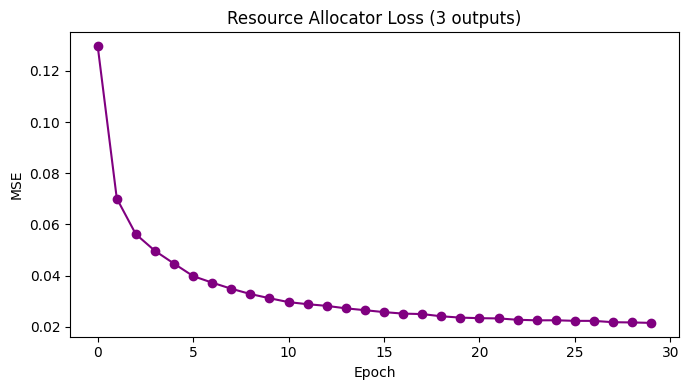

In [24]:
edge_mask = tasks["offload_label"] == 0
X_alloc_raw = features_raw[edge_mask]
y_alloc_np = np.clip(alloc_targets[edge_mask], 0.01, 1.0)

scaler_alloc = StandardScaler()
X_alloc_sc = np.clip(scaler_alloc.fit_transform(X_alloc_raw), -10, 10).astype(np.float32)
X_alloc = torch.tensor(X_alloc_sc, dtype=torch.float32)
y_alloc = torch.tensor(y_alloc_np, dtype=torch.float32)
print(f"Edge allocation samples: {X_alloc.shape[0]:,}  targets shape: {y_alloc.shape}")

class ResourceAllocator(nn.Module):
    '''
    Predicts fractional resource allocations for edge-assigned tasks.
    Outputs: [cpu_share, mem_share, bw_share] all in (0, 1) via Sigmoid.
    '''
    def __init__(self, inp):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(inp, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 3),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.layers(x)

allocator = ResourceAllocator(X_alloc.shape[1]).to(device)
alloc_losses = []
ALLOC_EPOCHS = 30
allocator_loaded_from_cache = False

if (not FORCE_RETRAIN_ALLOCATOR) and os.path.exists(allocator_model_path):
    try:
        payload = torch.load(allocator_model_path, map_location=device)
        allocator.load_state_dict(payload["state_dict"])
        alloc_losses = list(payload.get("alloc_losses", []))
        allocator_loaded_from_cache = True
        print(f"Loaded cached ResourceAllocator: {allocator_model_path}")
    except Exception as exc:
        print(f"Allocator cache ignored and retrained: {exc}")

if not allocator_loaded_from_cache:
    crit_alloc = nn.MSELoss()
    opt_alloc = optim.Adam(allocator.parameters(), lr=1e-3, weight_decay=1e-4)
    sch_alloc = optim.lr_scheduler.StepLR(opt_alloc, step_size=10, gamma=0.5)
    alloc_loader = DataLoader(TensorDataset(X_alloc, y_alloc), batch_size=512, shuffle=True, pin_memory=PIN_MEMORY)
    print("Training ResourceAllocator ...")
    for ep in range(ALLOC_EPOCHS):
        allocator.train(); total = 0.0
        for xb, yb in alloc_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt_alloc.zero_grad(set_to_none=True)
            loss = crit_alloc(allocator(xb), yb)
            loss.backward(); opt_alloc.step()
            total += float(loss.item())
        sch_alloc.step()
        avg = total / len(alloc_loader); alloc_losses.append(avg)
        if (ep + 1) % 5 == 0:
            print(f"  Epoch {ep+1:2d}/{ALLOC_EPOCHS}  loss={avg:.4f}")
    torch.save({"state_dict": allocator.state_dict(), "alloc_losses": alloc_losses, "ALLOC_EPOCHS": ALLOC_EPOCHS}, allocator_model_path)
    print(f"Saved ResourceAllocator cache: {allocator_model_path}")

if RUN_FULL_ANALYTICS and RUN_PLOTS and alloc_losses:
    plt.figure(figsize=(7,4))
    plt.plot(alloc_losses, marker="o", color="purple")
    plt.title("Resource Allocator Loss (3 outputs)"); plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.tight_layout(); plt.show()
else:
    print("Allocator loss plot skipped or no loss history available.")

## Cell 22 – Resource Allocator Evaluation (CPU / Memory / Bandwidth)

[FIX 5] Three-output allocator MAE:
  CPU MAE=0.1246  Mem MAE=0.0709  BW  MAE=0.0332  Overall=0.0762


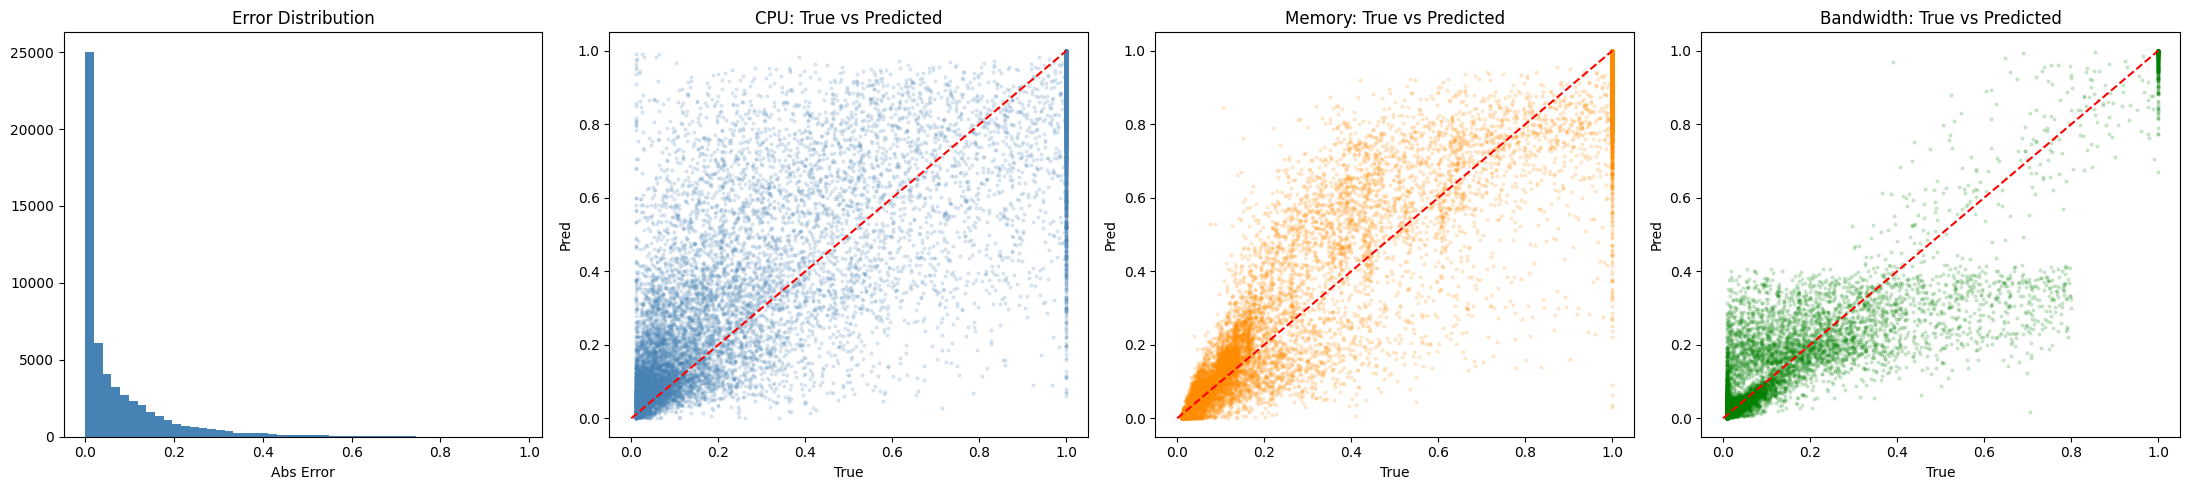

In [25]:
allocator.eval()
with torch.no_grad():
    preds_alloc = allocator(X_alloc.to(device)).cpu()

errors = torch.abs(preds_alloc - y_alloc).numpy()
print(f"[FIX 5] Three-output allocator MAE:")
print(f"  CPU MAE={errors[:,0].mean():.4f}  "
      f"Mem MAE={errors[:,1].mean():.4f}  "
      f"BW  MAE={errors[:,2].mean():.4f}  "
      f"Overall={errors.mean():.4f}")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].hist(errors.flatten(), bins=50, color="steelblue")
axes[0].set_title("Error Distribution"); axes[0].set_xlabel("Abs Error")

for col_i, (name, clr) in enumerate([("CPU","steelblue"),("Memory","darkorange"),("Bandwidth","green")]):
    ax = axes[col_i+1]
    ax.scatter(y_alloc[:,col_i].numpy(), preds_alloc[:,col_i].numpy(),
               alpha=0.15, s=4, color=clr)
    ax.plot([0,1],[0,1],"r--")
    ax.set_title(f"{name}: True vs Predicted")
    ax.set_xlabel("True"); ax.set_ylabel("Pred")

plt.tight_layout(); plt.show()


## Cell 23 – Edge Case Analysis

In [26]:
print("=" * 70); print("EDGE CASE ANALYSIS"); print("=" * 70)

def safe_col(df, col):
    return df[col] if col in df.columns else pd.Series(0, index=df.index)

cases = {
    "Emergency tasks"     : tasks["task_type"] == "emergency",
    "Firmware update"     : tasks["task_type"] == "firmware_update",
    "Corrupt tasks"       : safe_col(tasks,"is_corrupt") == 1,
    "Low-battery tasks"   : safe_col(tasks,"is_low_battery") == 1,
    "Impossible deadline" : safe_col(tasks,"impossible_deadline") == 1,
    "Has dependency"      : safe_col(tasks,"has_dependency") == 1,
    "Encrypted tasks"     : safe_col(tasks,"is_encrypted") == 1,
    "Real-time tasks"     : safe_col(tasks,"is_real_time") == 1,
}
rows_out = []
for label, mask in cases.items():
    sub = tasks[mask]
    if len(sub) == 0: continue
    valid = sub[(sub["edge_latency"]<EDGE_LAT_CAP)|(sub["cloud_latency"]<CLOUD_LAT_CAP)]
    rows_out.append({
        "Case":        label,
        "Count":       len(sub),
        "Edge%":       f"{(sub['offload_label']==0).mean()*100:.1f}",
        "Cloud%":      f"{(sub['offload_label']==1).mean()*100:.1f}",
        "Rej_flag%":   f"{sub['rejection_flag'].mean()*100:.1f}",
        "SLA_viol%":   f"{sub['sla_violated'].mean()*100:.1f}",
        "AvgEdgeLat":  f"{valid['edge_latency'].mean():.1f}"  if len(valid) else "N/A",
        "AvgCloudLat": f"{valid['cloud_latency'].mean():.1f}" if len(valid) else "N/A",
    })
print(pd.DataFrame(rows_out).to_string(index=False))

print("\n-- Network Event Impact on Rejection Rate (rejection_flag) --")
for col in ["is_outage","is_congestion","is_jitter_storm"]:
    if col not in network_state.columns: continue
    ets   = set(network_state.loc[network_state[col]==1,"timestep"])
    in_ev = tasks["arrival_time"].isin(ets)
    print(f"  {col:<25}: during={tasks.loc[in_ev,'rejection_flag'].mean():.3f}  "
          f"outside={tasks.loc[~in_ev,'rejection_flag'].mean():.3f}")


EDGE CASE ANALYSIS
               Case  Count Edge% Cloud% Rej_flag% SLA_viol% AvgEdgeLat AvgCloudLat
    Emergency tasks   6493  92.5    7.5      26.4      26.4       28.6       176.2
    Firmware update   7546   2.1   97.9       1.5       0.0      404.7       266.7
      Corrupt tasks    826  40.4   59.6      18.0      33.9        N/A         N/A
  Low-battery tasks   9420  18.7   81.3       4.4       8.9      175.0       204.4
Impossible deadline   1507   0.4   99.6     100.0      20.0      155.1       199.4
     Has dependency  13752  16.9   83.1       3.7       7.5      192.1       210.5
    Encrypted tasks  54764  21.8   78.2       5.7      11.4      189.1       209.0
    Real-time tasks  43254  30.9   69.1       7.2      19.1       39.5       187.2

-- Network Event Impact on Rejection Rate (rejection_flag) --
  is_outage                : during=0.182  outside=0.035
  is_congestion            : during=0.049  outside=0.028
  is_jitter_storm          : during=0.043  outside=0.038


## Cell 24 – Complete System Dashboard

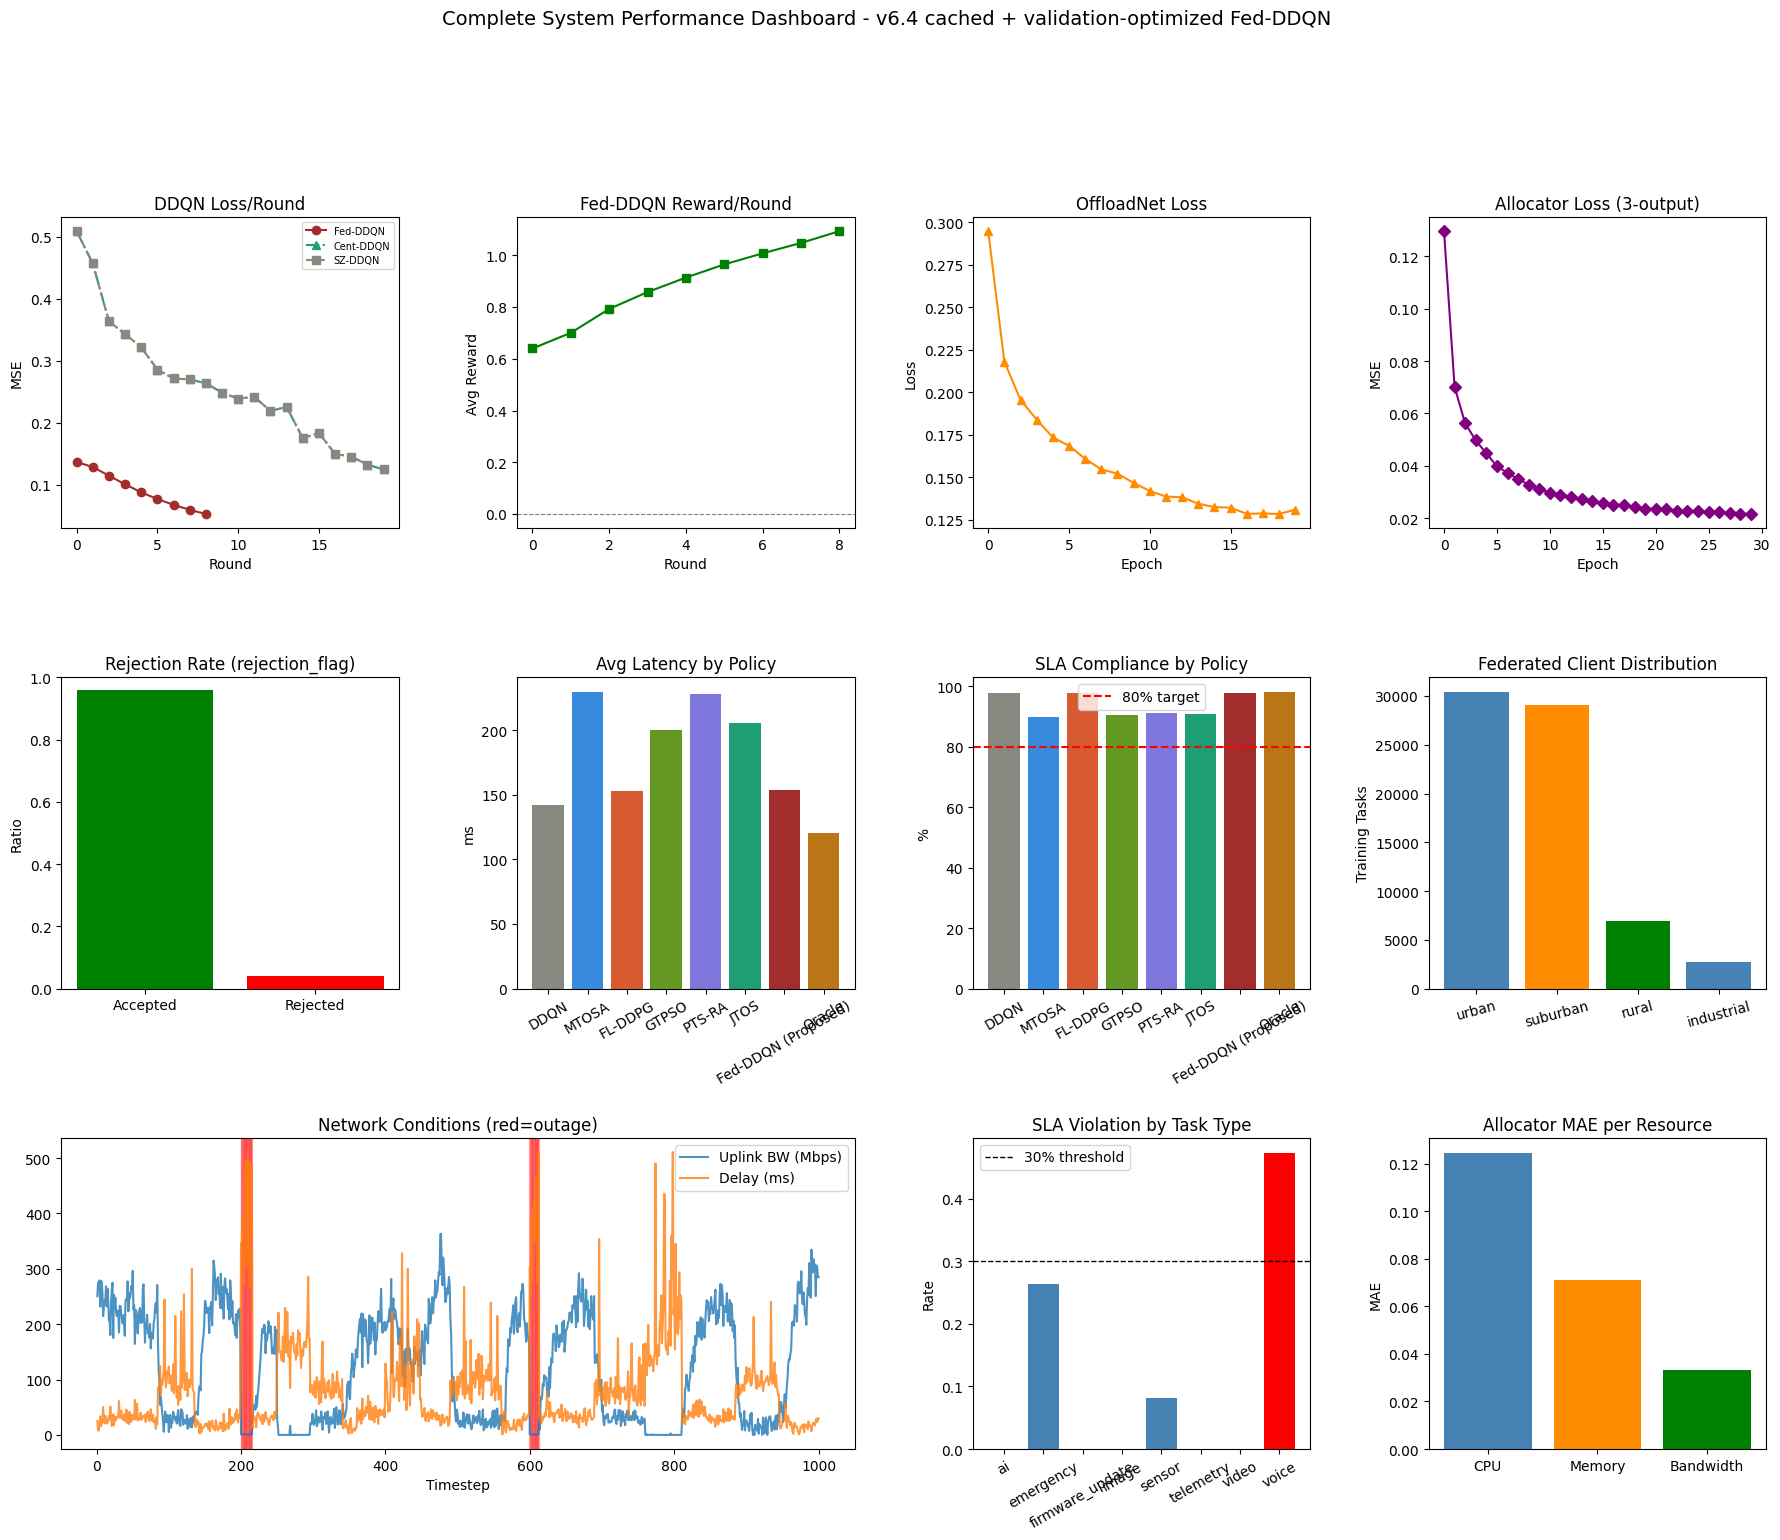

In [27]:
fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.35)

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(federated_losses, marker="o", color="#A32D2D",  label="Fed-DDQN")
ax1.plot(cent_losses,      marker="^", color="#1D9E75",  label="Cent-DDQN", linestyle="-.")
ax1.plot(local_losses,     marker="s", color="#888780",  label="SZ-DDQN",   linestyle="--")
ax1.set_title("DDQN Loss/Round"); ax1.set_xlabel("Round"); ax1.set_ylabel("MSE"); ax1.legend(fontsize=7)

ax2 = fig.add_subplot(gs[0,1])
ax2.plot(federated_rewards, marker="s", color="green")
ax2.axhline(0, color="gray", linestyle="--", lw=0.8)
ax2.set_title("Fed-DDQN Reward/Round"); ax2.set_xlabel("Round"); ax2.set_ylabel("Avg Reward")

ax3 = fig.add_subplot(gs[0,2])
ax3.plot(tr_losses, marker="^", color="darkorange")
ax3.set_title("OffloadNet Loss"); ax3.set_xlabel("Epoch"); ax3.set_ylabel("Loss")

ax4 = fig.add_subplot(gs[0,3])
ax4.plot(alloc_losses, marker="D", color="purple")
ax4.set_title("Allocator Loss (3-output)"); ax4.set_xlabel("Epoch"); ax4.set_ylabel("MSE")

ax5 = fig.add_subplot(gs[1,0])
rej_rate = tasks["rejection_flag"].mean()
ax5.bar(["Accepted","Rejected"],[1-rej_rate, rej_rate], color=["green","red"])
ax5.set_title("Rejection Rate (rejection_flag)"); ax5.set_ylim(0,1); ax5.set_ylabel("Ratio")

ax6 = fig.add_subplot(gs[1,1])
# Policy comparison latency
methods_short = df_compare.index.tolist()
ax6.bar(methods_short, df_compare["Avg Latency"].values,
        color=["#888780","#378ADD","#D85A30","#639922","#7F77DD","#1D9E75","#A32D2D","#BA7517"])
ax6.set_title("Avg Latency by Policy"); ax6.set_ylabel("ms")
ax6.tick_params(axis="x", rotation=30)

ax7 = fig.add_subplot(gs[1,2])
ax7.bar(methods_short, df_compare["SLA %"].values,
        color=["#888780","#378ADD","#D85A30","#639922","#7F77DD","#1D9E75","#A32D2D","#BA7517"])
ax7.axhline(80, color="red", linestyle="--", label="80% target"); ax7.legend()
ax7.set_title("SLA Compliance by Policy"); ax7.set_ylabel("%")
ax7.tick_params(axis="x", rotation=30)

ax8 = fig.add_subplot(gs[1,3])
zone_dist = train_df["zone"].value_counts()
ax8.bar(zone_dist.index, zone_dist.values, color=["steelblue","darkorange","green"])
ax8.set_title("Federated Client Distribution"); ax8.set_ylabel("Training Tasks")
ax8.tick_params(axis="x", rotation=15)

ax9 = fig.add_subplot(gs[2,0:2])
ax9.plot(network_state["timestep"], network_state["uplink_bandwidth"],  label="Uplink BW (Mbps)", alpha=0.8)
ax9.plot(network_state["timestep"], network_state["network_delay_ms"],  label="Delay (ms)", alpha=0.8)
if "is_outage" in network_state.columns:
    for ts in network_state.loc[network_state["is_outage"]==1,"timestep"]:
        ax9.axvspan(ts-0.5, ts+0.5, color="red", alpha=0.25)
ax9.set_title("Network Conditions (red=outage)"); ax9.set_xlabel("Timestep"); ax9.legend()

ax10 = fig.add_subplot(gs[2,2])
sla_by_type = tasks.groupby("task_type")["sla_violated"].mean()
cols10 = ["red" if v>0.3 else "steelblue" for v in sla_by_type.values]
ax10.bar(sla_by_type.index, sla_by_type.values, color=cols10)
ax10.axhline(0.3, color="black", linestyle="--", lw=1, label="30% threshold")
ax10.set_title("SLA Violation by Task Type"); ax10.set_ylabel("Rate")
ax10.tick_params(axis="x", rotation=30); ax10.legend()

ax11 = fig.add_subplot(gs[2,3])
# Allocator: 3-output error breakdown
mae_cpu = errors[:,0].mean(); mae_mem = errors[:,1].mean(); mae_bw = errors[:,2].mean()
ax11.bar(["CPU","Memory","Bandwidth"],[mae_cpu,mae_mem,mae_bw],
         color=["steelblue","darkorange","green"])
ax11.set_title("Allocator MAE per Resource"); ax11.set_ylabel("MAE")

plt.suptitle("Complete System Performance Dashboard - v6.4 cached + validation-optimized Fed-DDQN", fontsize=14, y=1.01)
plt.show() if RUN_PLOTS else plt.close()


## Cell 25 – Final Performance Summary

In [28]:
model.eval()
with torch.no_grad():
    lg2 = model(X_test.to(device))
    pr2 = torch.argmax(lg2, dim=1).cpu().numpy()
    pb2 = torch.softmax(lg2, dim=1)[:,1].cpu().numpy()

acc_net = accuracy_score(y_test_t.numpy(), pr2)
f1_net  = f1_score(y_test_t.numpy(), pr2, average="weighted")
fpr2,tpr2,_ = roc_curve(y_test_t.numpy(), pb2); auc_net = auc(fpr2, tpr2)

allocator.eval()
with torch.no_grad():
    ap    = allocator(X_alloc.to(device)).cpu()
    mae_a = torch.mean(torch.abs(ap - y_alloc)).item()

emerg_edge = float((tasks[tasks["task_type"]=="emergency"]["offload_label"]==0).mean())*100
n_rej_flag = tasks["rejection_flag"].sum()

print("=" * 70)
print(f"  {'METRIC':<45} {'VALUE':>22}")
print("=" * 70)
print(f"  {'[OffloadNet] Accuracy':<45} {acc_net*100:>21.2f}%")
print(f"  {'[OffloadNet] Weighted F1':<45} {f1_net:>22.4f}")
print(f"  {'[OffloadNet] ROC-AUC':<45} {auc_net:>22.4f}")
print("-" * 70)
print(f"  {'[Fed-DDQN] Avg Latency (ms)':<45} {avg_m:>22.4f}")
print(f"  {'[Fed-DDQN] Latency Improvement vs Cloud':<45} {improve:>21.2f}%")
print(f"  {'[Fed-DDQN] SLA Compliance':<45} {sla_r:>21.2f}%")
print(f"  {'[Fed-DDQN] Edge Usage':<45} {edge_cnt/n_eval*100:>21.2f}%")
print(f"  {'[Fed-DDQN] Best Validation Round':<45} {best_round:>22}")
print(f"  {'[Fed-DDQN] Best Validation Score':<45} {best_val_score:>22.4f}")
print(f"  {'[Fed-DDQN] Rounds Actually Run':<45} {rounds_ran:>22}")
print("-" * 70)
print(f"  {'[Allocator] CPU MAE':<45} {errors[:,0].mean():>22.4f}")
print(f"  {'[Allocator] Memory MAE':<45} {errors[:,1].mean():>22.4f}")
print(f"  {'[Allocator] Bandwidth MAE [FIX 5]':<45} {errors[:,2].mean():>22.4f}")
print(f"  {'[Allocator] Overall MAE':<45} {mae_a:>22.4f}")
print("-" * 70)
print(f"  {'[System] Rejection Flag Count [FIX 1]':<45} {n_rej_flag:>22,}")
print(f"  {'[System] Rejection Rate [FIX 1]':<45} {tasks['rejection_flag'].mean():>22.4f}")
print(f"  {'[System] SLA Violation Rate':<45} {tasks['sla_violated'].mean():>22.4f}")
print(f"  {'[System] Emergency->Edge Rate':<45} {emerg_edge:>21.2f}%")
print(f"  {'[System] Federated Zones [FIX 3]':<45} {str(zone_names):>22}")
print("=" * 70)
print("\nImprovements applied:")
print("  [FIX 1] rejection_flag properly computed (impossible_deadline OR SLA miss)")
print("  [v6.4] OffloadEnv: array-backed, action-aware contention and SLA-margin reward")
print("  [FIX 3] Non-IID federated clients: one per location_zone")
print("  [v6.4] Proposed Fed-DDQN: prioritized replay, persistent zone buffers, soft target updates, adaptive FedProx")
print("  [v6.5] Evaluation: cached/batched policy metrics; final df_compare is test-only")
if "df_ablation_summary" in globals() and len(df_ablation_summary):
    print(f"  [v6.5] Multi-seed ablation variants: {len(df_ablation_summary)} | seeds: {EXPERIMENT_SEEDS}")
if "df_scenario_final" in globals() and len(df_scenario_final):
    print(f"  [v6.5] Scenario-wise rows: {len(df_scenario_final)}")
if "results_loaded_from_cache" in globals():
    print(f"  [v6.5] Result-table cache loaded: {results_loaded_from_cache}")
print(f"  [cache] labels={labels_cache_loaded} features={feature_cache_loaded} fed_ddqn={fed_ddqn_loaded_from_cache} baselines={baseline_models_loaded_from_cache} allocator_targets={alloc_targets_loaded_from_cache} allocator={allocator_loaded_from_cache}")
print("\nSanity checks:")
print(f"  max edge_lat  = {tasks['edge_latency'].max():.2f} (cap={EDGE_LAT_CAP})")
print(f"  max cloud_lat = {tasks['cloud_latency'].max():.2f} (cap={CLOUD_LAT_CAP})")
print(f"  DDQN eval lat range = {model_lat.min():.2f} to {model_lat.max():.2f} ms")
print(f"  {'[Compare] Oracle Avg Latency (ceiling)':<45} "
      f"{df_compare.loc['Oracle','Avg Latency']:>22.3f} ms")
print(f"  {'[Compare] Cent-DDQN Avg Latency':<45} "
      f"{df_compare.loc['DDQN','Avg Latency']:>22.3f} ms")
print(f"  {'[Compare] SZ-DDQN Avg Latency':<45} "
      f"{df_compare.loc['FL-DDPG','Avg Latency']:>22.3f} ms")
print(f"  {'[Compare] Fed vs Cent improvement':<45} "
      f"{(df_compare.loc['DDQN','Avg Latency'] - df_compare.loc['Fed-DDQN (Proposed)','Avg Latency']):>+22.3f} ms")
print("-" * 70)
assert np.isnan(errors).sum() == 0, "NaN in allocator errors"
assert alloc_targets.shape[1] == 3, "Allocator must have 3 outputs"
print("  All sanity checks passed for v6.4.")


  METRIC                                                         VALUE
  [OffloadNet] Accuracy                                         97.50%
  [OffloadNet] Weighted F1                                      0.9748
  [OffloadNet] ROC-AUC                                          0.9811
----------------------------------------------------------------------
  [Fed-DDQN] Avg Latency (ms)                                 158.2308
  [Fed-DDQN] Latency Improvement vs Cloud                       27.95%
  [Fed-DDQN] SLA Compliance                                     97.79%
  [Fed-DDQN] Edge Usage                                         88.02%
  [Fed-DDQN] Best Validation Round                                   3
  [Fed-DDQN] Best Validation Score                            142.5922
  [Fed-DDQN] Rounds Actually Run                                     9
----------------------------------------------------------------------
  [Allocator] CPU MAE                                           0.1246
  [All